# <b><center>CSCI 5415 Data Mining</center></b>
# Author: Ying Yang, Carmen Avitia, Victoria Franco, Daniela Pedroza Rodriguez
# Group Project- Phase 4: EDA & Classification Code
## <b>Data Source</b>: 
### <ul>
### <li> Global Super Store Dataset: https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset/data</li>
### <li>E-commerce Consumer Behavior Dataset: https://www.kaggle.com/datasets/hunter0007/ecommerce-dataset-for-predictive-marketing-2023/data</li></ul>

<ol>
<li>KNN</li>
<li>Decision Tree</li>
<li>Random Forest</li>
<li>XGBoost</li>
</ol>

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore",category=Warning)
pd.set_option("display.width",500)
pd.set_option("display.max_rows",1000)
pd.set_option("display.max_columns",None)


## <hr/>
## <b>Data preprocessing </b>
## <hr/>

In [3]:
import kagglehub 
path2 = kagglehub.dataset_download("hunter0007/ecommerce-dataset-for-predictive-marketing-2023")
path1= kagglehub.dataset_download("apoorvaappz/global-super-store-dataset")

In [4]:
# Load Datasets
df = pd.read_csv(os.path.join(path1, "Global_Superstore2.csv"), encoding="latin1")
df2 = pd.read_csv(os.path.join(path2, "ECommerce_consumer behaviour.csv"), encoding="latin1")

df.shape, df2.shape

((51290, 24), (2019501, 12))

In [5]:
def data_preprocessing(data): 
    """
    Preprocess the data and return a DataFrame with feature statistics such as
    number of unique values, mean, standard deviation, etc.
    """
    # Initialize a dictionary to hold the statistics
    stats_dict = {
        "Feature": [],
        "Type": [],
        "Non-Null Count": [],
        "Missing Count": [],
        "Missing Rate": [],
        "Unique Values": [],
        "Mean": [],
        "Median": [],
        "Std": [],
        "Min": [],
        "25%": [],
        "50%": [],
        "75%": [],
        "Max": [],
        "Mode": [],
        "Skewness": [],
    }

    # Loop through each feature in the data
    for feature in data.columns:
        stats_dict["Feature"].append(feature)
        stats_dict["Type"].append(data[feature].dtype)
        stats_dict["Non-Null Count"].append(data[feature].shape[0] - data[feature].isnull().sum())
        stats_dict["Missing Count"].append(data[feature].isnull().sum())
        stats_dict["Missing Rate"].append(data[feature].isnull().sum()/data[feature].shape[0])
        stats_dict["Unique Values"].append(data[feature].nunique())
        
        # If the feature is numeric, calculate numerical statistics
        if data[feature].dtype in ['float64', 'int64']:
            stats_dict["Mean"].append(data[feature].mean())
            stats_dict["Median"].append(data[feature].median())
            stats_dict["Std"].append(data[feature].std())
            stats_dict["Min"].append(data[feature].min())
            stats_dict["25%"].append(data[feature].quantile(0.25))
            stats_dict["50%"].append(data[feature].median())
            stats_dict["75%"].append(data[feature].quantile(0.75))
            stats_dict["Max"].append(data[feature].max())
            stats_dict["Mode"].append(data[feature].mode()[0])
            stats_dict["Skewness"].append(data[feature].skew())
        else:
            # For categorical features, use the mode
            stats_dict["Mean"].append(None)
            stats_dict["Median"].append(None)
            stats_dict["Std"].append(None)
            stats_dict["Min"].append(None)
            stats_dict["25%"].append(None)
            stats_dict["50%"].append(None)
            stats_dict["75%"].append(None)
            stats_dict["Max"].append(None)
            stats_dict["Mode"].append(data[feature].mode()[0])
            stats_dict["Skewness"].append(None)
    
    # Convert the dictionary to a DataFrame
    stats_df = pd.DataFrame(stats_dict)

    # Return the statistics DataFrame
    return stats_df

In [6]:
# get the Global dataset statistic summary
df_stats = data_preprocessing(df.iloc[:, :])
df_stats

,Feature,Type,Non-Null Count,Missing Count,Missing Rate,Unique Values,Mean,Median,Std,Min,25%,50%,75%,Max,Mode,Skewness
0,Row ID,int64,51290,0,0.000000,51290,25645.500000,25645.500,14806.291990,1.000,12823.250000,25645.500,38467.7500,51290.000,1,-6.006947e-18
1,Order ID,object,51290,0,0.000000,25035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CA-2014-100111,NaN
2,Order Date,object,51290,0,0.000000,1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18-06-2014,NaN
3,Ship Date,object,51290,0,0.000000,1464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22-11-2014,NaN
4,Ship Mode,object,51290,0,0.000000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard Class,NaN
5,Customer ID,object,51290,0,0.000000,1590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PO-18850,NaN
6,Customer Name,object,51290,0,0.000000,795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Muhammed Yedwab,NaN
7,Segment,object,51290,0,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Consumer,NaN
8,City,object,51290,0,0.000000,3636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York City,NaN
9,State,object,51290,0,0.000000,1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,California,NaN


In [7]:
print(df.columns.tolist())

print(df2.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']
['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_id', 'add_to_cart_order', 'reordered', 'department_id', 'department', 'product_name']


In [8]:
# get the ECommerce dataset statistic summary
df2_stats = data_preprocessing(df2.iloc[:, :])
df2_stats

,Feature,Type,Non-Null Count,Missing Count,Missing Rate,Unique Values,Mean,Median,Std,Min,25%,50%,75%,Max,Mode,Skewness
0,order_id,int64,2019501,0,0.000000,200000,1.707013e+06,1705004.0,985983.196234,10.0,852649.0,1705004.0,2559031.0,3421080.0,790903,0.002581
1,user_id,int64,2019501,0,0.000000,105273,1.030673e+05,102690.0,59491.165074,2.0,51584.0,102690.0,154600.0,206209.0,176478,0.007486
2,order_number,int64,2019501,0,0.000000,100,1.715138e+01,11.0,17.525765,1.0,5.0,11.0,24.0,100.0,1,1.777229
3,order_dow,int64,2019501,0,0.000000,7,2.735367e+00,3.0,2.093882,0.0,1.0,3.0,5.0,6.0,0,0.180367
4,order_hour_of_day,int64,2019501,0,0.000000,24,1.343948e+01,13.0,4.241008,0.0,10.0,13.0,16.0,23.0,10,-0.046280
5,days_since_prior_order,float64,1895159,124342,0.061571,31,1.138603e+01,8.0,8.970980,0.0,5.0,8.0,15.0,30.0,7.0,1.000819
6,product_id,int64,2019501,0,0.000000,134,7.120590e+01,83.0,38.207275,1.0,31.0,83.0,107.0,134.0,24,-0.166926
7,add_to_cart_order,int64,2019501,0,0.000000,137,8.363173e+00,6.0,7.150059,1.0,3.0,6.0,11.0,137.0,1,1.887272
8,reordered,int64,2019501,0,0.000000,2,5.897427e-01,1.0,0.491880,0.0,0.0,1.0,1.0,1.0,1,-0.364897
9,department_id,int64,2019501,0,0.000000,21,9.928349e+00,9.0,6.282933,1.0,4.0,9.0,16.0,21.0,4,0.149656


In [9]:
# check if has duplicated values
df.duplicated().sum()
df2.duplicated().sum()

np.int64(0)

In [10]:
# Drop Postal Code if it exists
if "Postal Code" in df.columns:
    df.drop("Postal Code", axis=1, inplace=True)

# Fill days_since_prior_order with median
if "days_since_prior_order" in df2.columns:
    df2["days_since_prior_order"] = df2["days_since_prior_order"].fillna(df2["days_since_prior_order"].median())   #fill with median

# Check missing values
print("Global dataset:\n",df.isnull().sum())
print("\nEcommerce dataset:\n",df2.isnull().sum())

Global dataset:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

Ecommerce dataset:
 order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
department_id             0
department                0
product_name              0
dtype: int64


## <b>KNN</b>

### Global Superstore Dataset

In [ ]:
# --------------> Identify which weekdays customers prefer to purchase items <-------------------.
if "Order Date" in df.columns:
    df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce", dayfirst=True)    
    # Extract the weekday
    # 0 = Monday, 6 = Sunday
    df['Order Weekday'] = df['Order Date'].dt.weekday  
        
    # Optional: get weekday names
    df['Order Weekday Name'] = df['Order Date'].dt.day_name()
    
    # Sort orders by customer and date
    df = df.sort_values(['Customer ID', 'Order Date'])
    
    # Calculate days since previous order
    df['days_since_prior_order'] = df.groupby('Customer ID')['Order Date'].diff().dt.days
    
    # Handle the first order
    ## The first order for each customer will have NaN because there is no previous order. Fill it with 0 or leave as NaN:
    df['days_since_prior_order'] = df['days_since_prior_order'].fillna(0)

In [ ]:
# Analyze average shipping days by shipping method (ship mode)

if "Order Date" in df.columns and "Ship Date" in df.columns:
    # Convert dates to datetime
    df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
    
    # Calculate shipping days
    df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
    
    # Summary statistics
    shipmode_stats = df.groupby('Ship Mode')['Shipping Days'].describe()
    print(shipmode_stats)

                  count      mean       std  min  25%  50%  75%  max
Ship Mode                                                           
First Class      7505.0  2.181746  0.751518  1.0  2.0  2.0  3.0  3.0
Same Day         2701.0  0.037394  0.189759  0.0  0.0  0.0  0.0  1.0
Second Class    10309.0  3.230187  1.174392  2.0  2.0  3.0  4.0  5.0
Standard Class  30775.0  4.998018  1.002254  4.0  4.0  5.0  6.0  7.0


In [ ]:
# Analyze average shipping days by shipping method (ship mode)

if "Order Date" in df.columns and "Ship Date" in df.columns:
    # Convert dates to datetime
    df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
    
    # Calculate shipping days
    df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
    
    # Summary statistics
    shipmode_stats = df.groupby('Ship Mode')['Shipping Days'].describe()
    print(shipmode_stats)

                  count      mean       std  min  25%  50%  75%  max
Ship Mode                                                           
First Class      7505.0  2.181746  0.751518  1.0  2.0  2.0  3.0  3.0
Same Day         2701.0  0.037394  0.189759  0.0  0.0  0.0  0.0  1.0
Second Class    10309.0  3.230187  1.174392  2.0  2.0  3.0  4.0  5.0
Standard Class  30775.0  4.998018  1.002254  4.0  4.0  5.0  6.0  7.0


In [ ]:
# Create a column named "customer_order" 
if "Customer ID" in df.columns and "Order ID" in df.columns:

    # Example: number of orders per customer
    customer_orders = df.groupby('Customer ID')['Order ID'].nunique()
    print(customer_orders.describe())

count    1590.000000
mean       16.196855
std        10.619199
min         1.000000
25%         6.000000
50%        14.000000
75%        26.000000
max        41.000000
Name: Order ID, dtype: float64


In [ ]:
df['customer_value'].value_counts()

customer_value
Low     29874
High    21416
Name: count, dtype: int64

In [ ]:
# Define customer value
df['customer_value'] = df["customer_value"].map({'High':1, 'Low':0})

In [ ]:
# Rename columns: lower letters and connect with underscores
df.columns = ["_".join(col.split()).lower() for col in df.columns]

In [ ]:
num_cols=[col for col in df.columns if df[col].dtypes!="O" and col not in ["row_id","order_date","order_weekday","ship_date"]]

# outlier threshold:
def outlier_thresholds(dataframe,col_name,q1=0.05,q3=0.95):
    q1=dataframe[col_name].quantile(q1)
    q3=dataframe[col_name].quantile(q3)
    IQR=q3-q1
    
    up_limit=q3+1.5*IQR
    low_limit=q1-1.5*IQR
    
    return low_limit,up_limit

# check outliers:
def check_outliers(dataframe,col_name):
    low_limit,up_limit=outlier_thresholds(dataframe,col_name)
    if dataframe[(dataframe[col_name]<low_limit) | (dataframe[col_name]>up_limit)].any(axis=None):
         return True 
   
    else:
         return False
    
def replace_with_thresholds(dataframe, col):
    low_limit, up_limit = outlier_thresholds(dataframe, col)
    if low_limit > 0:
        dataframe.loc[(dataframe[col] < low_limit), col] = low_limit
        dataframe.loc[(dataframe[col] > up_limit), col] = up_limit
    else:
        dataframe.loc[(dataframe[col] > up_limit), col] = up_limit   
        
for col in num_cols:
    print(col, check_outliers(df, col))
    print(col, replace_with_thresholds(df, col))

sales True
sales None
quantity False
quantity None
discount False
discount None
profit True
profit None
shipping_cost True
shipping_cost None
days_since_prior_order True
days_since_prior_order None
shipping_days False
shipping_days None
customer_value False
customer_value None


In [ ]:
# Coverted order_date and ship_date to datetime
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['ship_year'] = df['ship_date'].dt.year
df['ship_month'] = df['ship_date'].dt.month


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
import time

# ---------------------------
# Drop non-predictive columns
# ---------------------------
drop_cols = ['row_id', 'order_id', 'customer_id', 'product_id', 'order_date', 'ship_date']
df_clean = df.drop(columns=drop_cols, errors='ignore')

# ---------------------------
# Encode categorical columns
# ---------------------------
obj_cols = df_clean.select_dtypes(include='object').columns
le_dict = {}
for col in obj_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le  # store encoder for inverse transform if needed

# ---------------------------
# Handle missing values
# ---------------------------
imputer = SimpleImputer(strategy='median')
X_global = df_clean.drop('customer_value', axis=1)
y_global = df_clean['customer_value']

X_imputed = imputer.fit_transform(X_global)

# ---------------------------
# Train/Test Split
# ---------------------------
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_imputed, y_global, test_size=0.3, random_state=42, stratify=y_global
)

# ---------------------------
# Standardize numeric features
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_global)
X_test_scaled = scaler.transform(X_test_global)

# ---------------------------
# Handle class imbalance using SMOTE
# ---------------------------
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train_global)

# ---------------------------
# Define model and hyperparameter grid
# ---------------------------
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 7, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# ---------------------------
# Grid Search with 3-Fold CV
# ---------------------------
start_time = time.time()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

# ---------------------------
# Evaluate best model
# ---------------------------
best_knn_global = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV AUC:", grid_search.best_score_)
print(f"Total training time: {end_time - start_time:.2f} seconds\n")

# --- Final test evaluation ---
y_pred_test_global = best_knn_global.predict(X_test_scaled)
y_prob_test_global = best_knn_global.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test_global, y_pred_test_global))
print("Test ROC-AUC:", roc_auc_score(y_test_global, y_prob_test_global))
print("Test PR-AUC:", average_precision_score(y_test_global, y_prob_test_global))
print("\nClassification Report (Test):")
print(classification_report(y_test_global, y_pred_test_global))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV AUC: 0.8741239808270534
Total training time: 24.07 seconds

Test Accuracy: 0.7519334503152011
Test ROC-AUC: 0.8368765223160131
Test PR-AUC: 0.752893779704096

Classification Report (Test):
              precision    recall  f1-score   support

         0.0       0.80      0.76      0.78      8962
         1.0       0.69      0.74      0.71      6425

    accuracy                           0.75     15387
   macro avg       0.75      0.75      0.75     15387
weighted avg       0.76      0.75      0.75     15387



 KNN Model Metrics (Global Dataset):
  • PR-AUC: 0.753
  • F1 Score: 0.715
  • Balanced Accuracy: 0.751
  • Baseline (Majority Class) Balanced Accuracy: 0.500


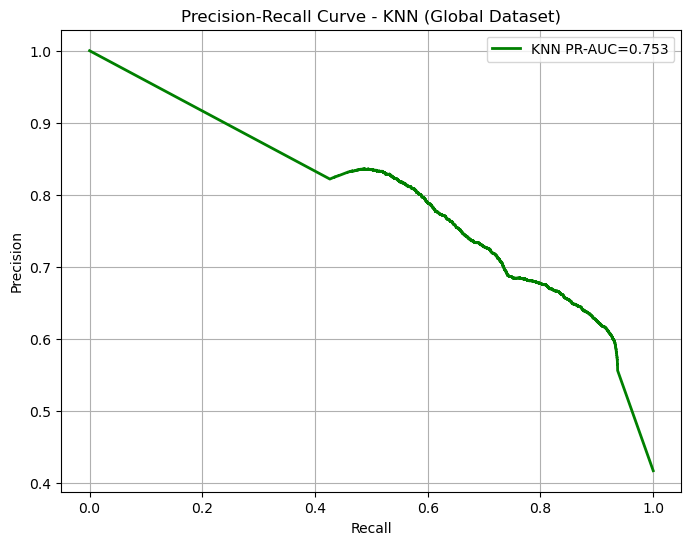

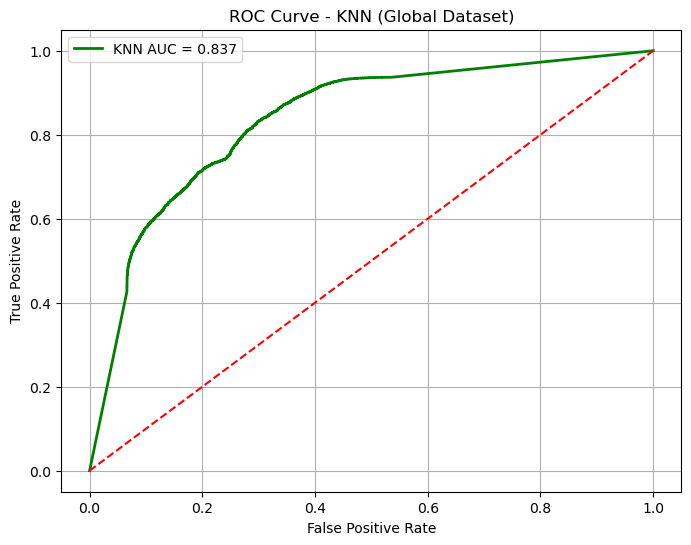

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt

# --- Compute metrics ---
precision, recall, _ = precision_recall_curve(y_test_global, y_prob_test_global)
pr_auc = average_precision_score(y_test_global, y_prob_test_global)

# Predicted labels using 0.5 threshold
y_pred_global = (y_prob_test_global >= 0.5).astype(int)

f1 = f1_score(y_test_global, y_pred_global)
bal_acc = balanced_accuracy_score(y_test_global, y_pred_global)

# --- Baseline (majority class) ---
majority_class = np.bincount(y_test_global).argmax()
baseline_preds = np.full_like(y_test_global, majority_class)
baseline_bal_acc = balanced_accuracy_score(y_test_global, baseline_preds)

# --- Display metrics ---
print(f" KNN Model Metrics (Global Dataset):")
print(f"  • PR-AUC: {pr_auc:.3f}")
print(f"  • F1 Score: {f1:.3f}")
print(f"  • Balanced Accuracy: {bal_acc:.3f}")
print(f"  • Baseline (Majority Class) Balanced Accuracy: {baseline_bal_acc:.3f}")

# --- Plot Precision-Recall Curve ---
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'KNN PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - KNN (Global Dataset)')
plt.legend()
plt.grid(True)
plt.show()


from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test_global, y_prob_test_global)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr,
    color='green',
    linewidth=2,
    label=f'KNN AUC = {roc_auc_score(y_test_global, y_prob_test_global):.3f}'
)
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (Global Dataset)')
plt.legend()
plt.grid(True)
plt.show()



Confusion Matrix (KNN):
 [[2340 6622]
 [1169 5256]]


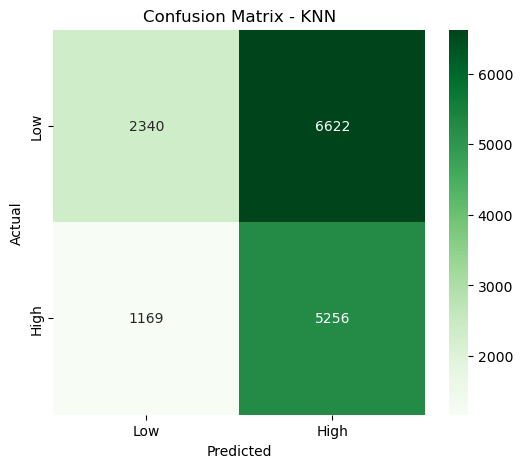

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Predict on test set ---
y_pred_global = best_knn_global.predict(X_test_global)

# --- Compute confusion matrix ---
cm_global = confusion_matrix(y_test_global, y_pred_global)

print("Confusion Matrix (KNN):\n", cm_global)

# --- Plot ---
plt.figure(figsize=(6,5))
sns.heatmap(cm_global, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()


In [ ]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on test set
r = permutation_importance(
    best_knn_global,
    X_test_scaled,
    y_test_global,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

# Create DataFrame for importance
feature_names = X_global.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("\nTop 10 Most Important Features (Permutation Importance):")
print(importance_df.head(10))



Top 10 Most Important Features (Permutation Importance):
               feature  importance_mean  importance_std
1        customer_name         0.036737        0.001323
7               region         0.035238        0.002344
2              segment         0.034634        0.002113
6               market         0.032637        0.002059
3                 city         0.031607        0.001663
4                state         0.028705        0.002398
16      order_priority         0.022844        0.001207
20       shipping_days         0.022212        0.001186
17       order_weekday         0.019998        0.001357
18  order_weekday_name         0.018393        0.001376


### <b>E-Commerce Dataset</b>

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019501 entries, 0 to 2019500
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            float64
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
 6   product_id              int64  
 7   add_to_cart_order       float64
 8   reordered               int64  
 9   department_id           int64  
 10  department              object 
 11  product_name            object 
dtypes: float64(3), int64(7), object(2)
memory usage: 184.9+ MB


In [ ]:
# Deal with the outlier columns, re
num_cols = ['order_number', 'order_dow', 'order_hour_of_day', 'add_to_cart_order']
for col in num_cols:
    print(col, check_outliers(df2, col))
    print(col, replace_with_thresholds(df2,col))
    

order_number False
order_number None
order_dow False
order_dow None
order_hour_of_day False
order_hour_of_day None
add_to_cart_order True
add_to_cart_order None


In [ ]:
import time
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE

# ---------------------------
# Drop non-predictive columns
# ---------------------------
drop_cols = ['order_id', 'user_id', 'product_id', 'days_since_prior_order', 'department_id']
df_ecom_clean = df2.drop(columns=drop_cols, errors='ignore')

# ---------------------------
# Encode categorical columns
# ---------------------------
obj_cols = df_ecom_clean.select_dtypes(include='object').columns
le_dict = {}
for col in obj_cols:
    le = LabelEncoder()
    df_ecom_clean[col] = le.fit_transform(df_ecom_clean[col].astype(str))
    le_dict[col] = le  # store encoder if inverse transform needed

# ---------------------------
# Handle missing values
# ---------------------------
imputer = SimpleImputer(strategy='median')
X_ecom = df_ecom_clean.drop('reordered', axis=1)
y_ecom = df_ecom_clean['reordered']
X_ecom_imputed = imputer.fit_transform(X_ecom)

# ---------------------------
# Train/Test Split
# ---------------------------
X_train_ecom, X_test_ecom, y_train_ecom, y_test_ecom = train_test_split(
    X_ecom_imputed, y_ecom, test_size=0.3, random_state=42, stratify=y_ecom
)

# ---------------------------
# Standardize numeric features
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ecom)
X_test_scaled = scaler.transform(X_test_ecom)

# ---------------------------
# Handle class imbalance using SMOTE
# ---------------------------
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train_ecom)

# ---------------------------
# Define model and hyperparameter distributions
# ---------------------------
knn = KNeighborsClassifier()
param_dist = {
    'n_neighbors': [3, 7, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# ---------------------------
# Randomized Search with 3-Fold CV
# ---------------------------
start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=10,                # number of random combinations
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

# ---------------------------
#  Evaluate best model
# ---------------------------
best_knn_ecom = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)
print(f"Total running time: {end_time - start_time:.2f} seconds\n")

# --- Final test evaluation ---
y_pred_test_ecom = best_knn_ecom.predict(X_test_scaled)
y_prob_test_ecom = best_knn_ecom.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test_ecom, y_pred_test_ecom))
print("Test ROC-AUC:", roc_auc_score(y_test_ecom, y_prob_test_ecom))
print("Test PR-AUC:", average_precision_score(y_test_ecom, y_prob_test_ecom))
print("\nClassification Report (Test):")
print(classification_report(y_test_ecom, y_pred_test_ecom))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'weights': 'uniform', 'n_neighbors': 11, 'metric': 'manhattan'}
Best CV ROC-AUC: 0.7771122171855517
Total running time: 169.95 seconds

Test Accuracy: 0.6912838305127829
Test ROC-AUC: 0.74568829819812
Test PR-AUC: 0.7706175533546922

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.62      0.65      0.63    248555
           1       0.75      0.72      0.73    357296

    accuracy                           0.69    605851
   macro avg       0.68      0.69      0.68    605851
weighted avg       0.69      0.69      0.69    605851



  KNN Model Metrics:
  • PR-AUC: 0.771
  • F1 Score: 0.733
  • Balanced Accuracy: 0.685
  • Baseline (Majority Class) Balanced Accuracy: 0.500


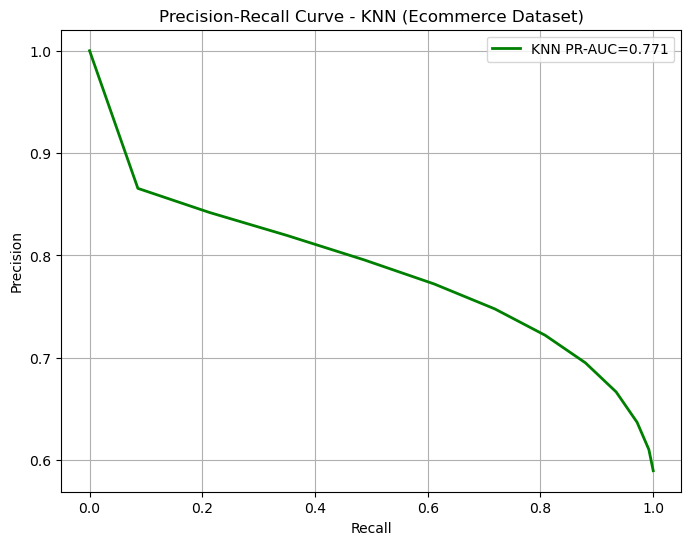

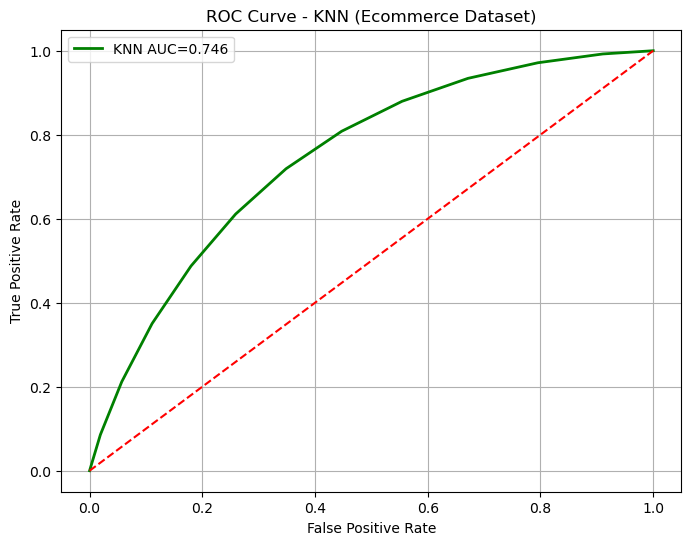

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt

# --- Compute metrics ---
precision, recall, _ = precision_recall_curve(y_test_ecom, y_prob_test_ecom)
pr_auc = average_precision_score(y_test_ecom, y_prob_test_ecom)

# Predicted labels using 0.5 threshold
y_pred_ecom = (y_prob_test_ecom >= 0.5).astype(int)

f1 = f1_score(y_test_ecom, y_pred_ecom)
bal_acc = balanced_accuracy_score(y_test_ecom, y_pred_ecom)

# --- Baseline (majority class) ---
majority_class = np.bincount(y_test_ecom).argmax()
baseline_preds = np.full_like(y_test_ecom, majority_class)
baseline_bal_acc = balanced_accuracy_score(y_test_ecom, baseline_preds)

# --- Display metrics ---
print(f"  KNN Model Metrics:")
print(f"  • PR-AUC: {pr_auc:.3f}")
print(f"  • F1 Score: {f1:.3f}")
print(f"  • Balanced Accuracy: {bal_acc:.3f}")
print(f"  • Baseline (Majority Class) Balanced Accuracy: {baseline_bal_acc:.3f}")

# --- Plot Precision-Recall Curve ---
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'KNN PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - KNN (Ecommerce Dataset)')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import roc_curve
# --- Plot ROC curve ---
fpr, tpr, _ = roc_curve(y_test_ecom, y_prob_test_ecom)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', linewidth=2, label=f'KNN AUC={roc_auc_score(y_test_ecom, y_prob_test_ecom):.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (Ecommerce Dataset)')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
 [[161906  86649]
 [100387 256909]]


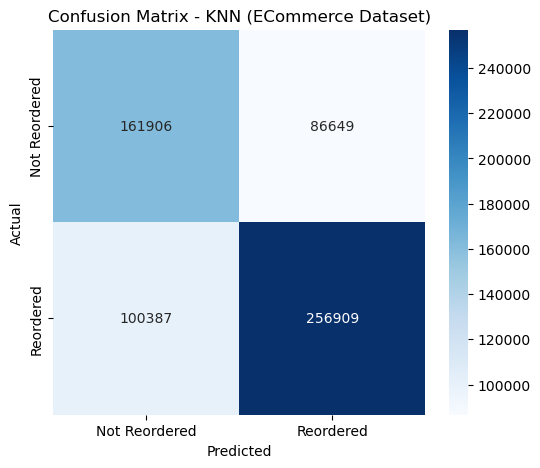

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# -----------------------------
# Confusion Matrix on Test Set
# -----------------------------
y_test_pred = best_knn_ecom.predict(X_test_ecom)
cm = confusion_matrix(y_test_ecom, y_pred_test_ecom)

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Reordered', 'Reordered'],
            yticklabels=['Not Reordered', 'Reordered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN (ECommerce Dataset)')
plt.show()


Top Feature Importances (Permutation):
             feature  importance_mean  importance_std
0       order_number         0.193438        0.015583
5       product_name         0.038093        0.004053
4         department         0.031733        0.007687
3  add_to_cart_order         0.020383        0.007534
1          order_dow         0.014989        0.004610
2  order_hour_of_day        -0.004672        0.000357


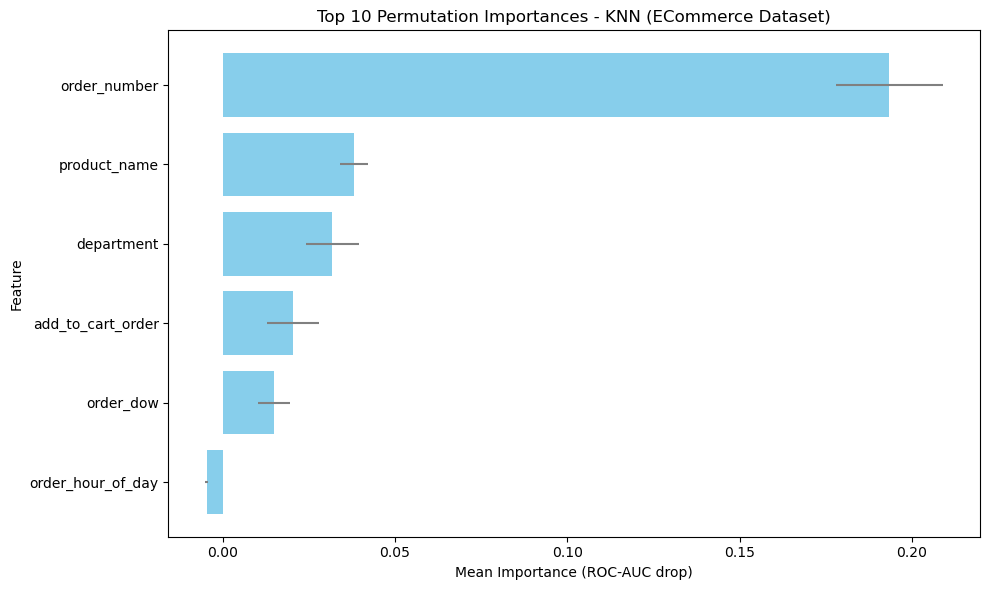

In [ ]:
# ===========================================
#  FAST Permutation Importance for KNN Model
# ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ---------------------------
# Sample a smaller test subset for speed
# ---------------------------
sample_size = 1000  # adjust smaller/larger as needed
if len(X_test_scaled) > sample_size:
    X_sample = X_test_scaled[:sample_size]
    y_sample = y_test_ecom[:sample_size]
else:
    X_sample = X_test_scaled
    y_sample = y_test_ecom

# ---------------------------
# Run permutation importance
# ---------------------------
result = permutation_importance(
    best_knn_ecom,
    X_sample,
    y_sample,
    scoring='roc_auc',
    n_repeats=3,        # reduce from 10 → 3 for speed
    random_state=42,
    n_jobs=1            # use 1 core for stability; can try -1 if CPU allows
)

# ---------------------------
# Create feature importance DataFrame
# ---------------------------
# Handle feature names based on input type
try:
    feature_names = X_ecom.columns  # if X_ecom is a DataFrame
except AttributeError:
    feature_names = [f"feature_{i}" for i in range(X_sample.shape[1])]  # fallback

feat_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=False)

print("\nTop Feature Importances (Permutation):")
print(feat_importance_df.head(10))

# ---------------------------
# Plot top 10 feature importances
# ---------------------------
top_n = 10
top_features = feat_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance_mean'],
         xerr=top_features['importance_std'],
         color='skyblue', ecolor='gray')
plt.gca().invert_yaxis()
plt.xlabel('Mean Importance (ROC-AUC drop)')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Permutation Importances - KNN (ECommerce Dataset)')
plt.tight_layout()
plt.show()


## <b>Decision Tree</b>

### <b>Global Superstore Dataset</b>

In [ ]:

# ---------------------------
# Train/Test Split
# ---------------------------
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_imputed, y_global, test_size=0.3, random_state=42, stratify=y_global
)

# ---------------------------
# Standardize numeric features (optional for DT)
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_global)
X_test_scaled = scaler.transform(X_test_global)

# ---------------------------
# Handle class imbalance using SMOTE
# ---------------------------
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train_global)

# ---------------------------
# Define DT model and hyperparameter distribution
# ---------------------------
dt = DecisionTreeClassifier(random_state=42)
param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [8, 10, 12, 14],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

# ---------------------------
# Randomized Search with 3-Fold CV
# ---------------------------
start_time = time.time()
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

# ---------------------------
# Evaluate best model
# ---------------------------
best_dt = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)
print(f"Training time: {end_time - start_time:.2f} seconds\n")

y_pred_global = best_dt.predict(X_test_scaled)
y_prob_test_global = best_dt.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test_global, y_pred_global))
print("Test ROC-AUC:", roc_auc_score(y_test_global, y_prob_test_global))
print("Test PR-AUC:", average_precision_score(y_test_global, y_prob_test_global))
print("\nClassification Report:\n", classification_report(y_test_global, y_pred_global))


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters: {'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': None, 'max_depth': 14, 'criterion': 'entropy', 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.740196986496072
Training time: 11.16 seconds

Test Accuracy: 0.6521739130434783
Test ROC-AUC: 0.7492229621480058
Test PR-AUC: 0.6404407536147843

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.50      0.63      8962
         1.0       0.55      0.86      0.67      6425

    accuracy                           0.65     15387
   macro avg       0.69      0.68      0.65     15387
weighted avg       0.72      0.65      0.65     15387



 KNN Model Metrics (Global Dataset):
  • PR-AUC: 0.640
  • F1 Score: 0.673
  • Balanced Accuracy: 0.681
  • Baseline (Majority Class) Balanced Accuracy: 0.500


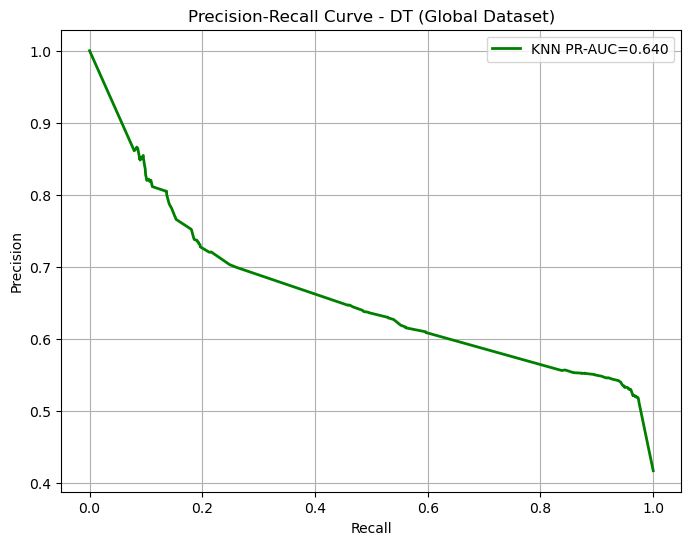

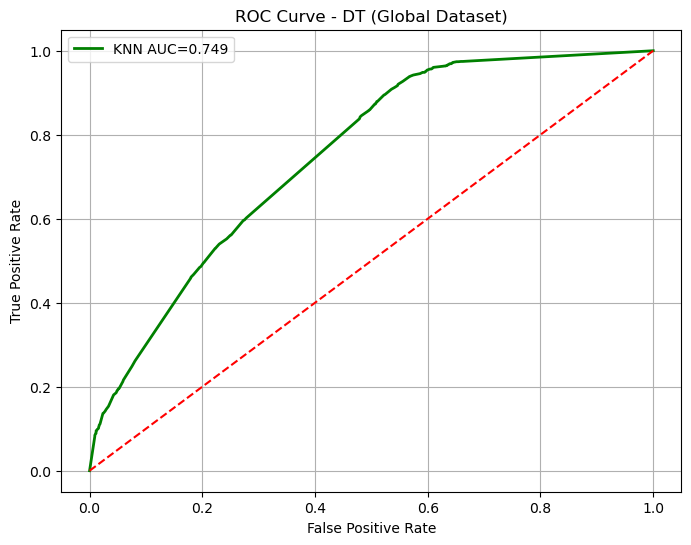

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt

# --- Compute metrics ---
precision, recall, _ = precision_recall_curve(y_test_global, y_prob_test_global)
pr_auc = average_precision_score(y_test_global, y_prob_test_global)

# Predicted labels using 0.5 threshold
y_pred_global = (y_prob_test_global >= 0.5).astype(int)

f1 = f1_score(y_test_global, y_pred_global)
bal_acc = balanced_accuracy_score(y_test_global, y_pred_global)

# --- Baseline (majority class) ---
majority_class = np.bincount(y_test_global).argmax()
baseline_preds = np.full_like(y_test_global, majority_class)
baseline_bal_acc = balanced_accuracy_score(y_test_global, baseline_preds)

# --- Display metrics ---
print(f" KNN Model Metrics (Global Dataset):")
print(f"  • PR-AUC: {pr_auc:.3f}")
print(f"  • F1 Score: {f1:.3f}")
print(f"  • Balanced Accuracy: {bal_acc:.3f}")
print(f"  • Baseline (Majority Class) Balanced Accuracy: {baseline_bal_acc:.3f}")

# --- Plot Precision-Recall Curve ---
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'KNN PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - DT (Global Dataset)')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import roc_auc_score, roc_curve

# --- Plot ROC curve ---
fpr, tpr, _ = roc_curve(y_test_global, y_prob_test_global)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', linewidth=2, label=f'KNN AUC={roc_auc_score(y_test_global, y_prob_test_global):.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DT (Global Dataset)')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
 [[4506 4456]
 [ 902 5523]]


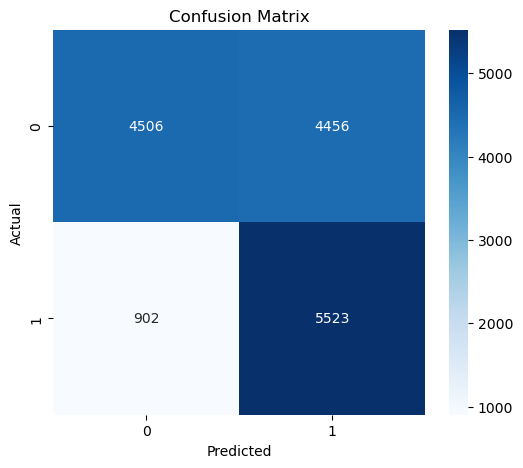

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Confusion Matrix
# ---------------------------
cm = confusion_matrix(y_test_global, y_pred_global)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Top 10 Feature Importance (Decision Tree):
                   feature  importance
7                   region    0.300185
1            customer_name    0.219973
12                quantity    0.166685
6                   market    0.066131
2                  segment    0.048135
13                discount    0.027059
19  days_since_prior_order    0.018179
14                  profit    0.017638
3                     city    0.014634
10            product_name    0.014088


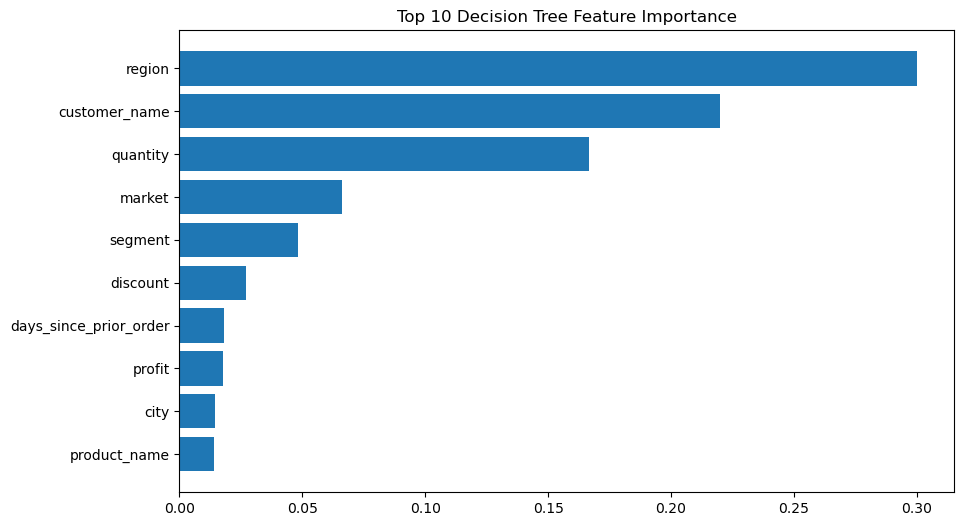

In [ ]:
# ---------------------------
# Feature Importance (Top 10)
# ---------------------------
feat_importance = pd.DataFrame({
    'feature': X_global.columns,
    'importance': best_dt.feature_importances_
}).sort_values(by='importance', ascending=False).head(10)  # keep top 10

print("\nTop 10 Feature Importance (Decision Tree):")
print(feat_importance)

# --- Plot top 10 feature importance ---
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['feature'], feat_importance['importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Decision Tree Feature Importance")
plt.show()


### <b>E-Commerce Dataset</b>

In [ ]:

# ---------------------------
# Train/Test Split
# ---------------------------
X_train_ecom, X_test_ecom, y_train_ecom, y_test_ecom = train_test_split(
    X_ecom_imputed, y_ecom, test_size=0.3, random_state=42, stratify=y_ecom
)

# ---------------------------
# Standardize numeric features (optional for DT)
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ecom)
X_test_scaled = scaler.transform(X_test_ecom)

# ---------------------------
# Handle class imbalance using SMOTE
# ---------------------------
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train_ecom)

# ---------------------------
# Define Decision Tree model and hyperparameter distributions
# ---------------------------
dt = DecisionTreeClassifier(random_state=42)
param_dist = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# ---------------------------
# Randomized Search with 3-Fold CV
# ---------------------------
start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

# ---------------------------
# Evaluate best model
# ---------------------------
best_dt_ecom = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)
print(f"Total running time: {end_time - start_time:.2f} seconds\n")

# --- Final test evaluation ---
#y_pred_test_ecom = best_dt_ecom.predict(X_test_scaled)
#y_test_prob_ecom = best_dt_ecom.predict_proba(X_test_scaled)[:, 1]

y_pred_test_ecom = best_dt_ecom.predict(X_test_scaled)
y_test_prob_ecom = best_dt_ecom.predict_proba(X_test_scaled)[:, 1]

# Accuracy uses class labels
print("Test Accuracy:", accuracy_score(y_test_ecom, y_pred_test_ecom))

# ROC-AUC and PR-AUC use probabilities
print("Test ROC-AUC:", roc_auc_score(y_test_ecom, y_test_prob_ecom))
print("Test PR-AUC:", average_precision_score(y_test_ecom, y_test_prob_ecom))
print("\nClassification Report (Test):")
print(classification_report(y_test_ecom, y_pred_test_ecom))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 9, 'criterion': 'gini'}
Best CV ROC-AUC: 0.7700464991371069
Total running time: 29.75 seconds

Test Accuracy: 0.7093295216150506
Test ROC-AUC: 0.7691567226551195
Test PR-AUC: 0.7983656265536734

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.65      0.63      0.64    248555
           1       0.75      0.76      0.76    357296

    accuracy                           0.71    605851
   macro avg       0.70      0.70      0.70    605851
weighted avg       0.71      0.71      0.71    605851



  KNN Model Metrics:
  • PR-AUC: 0.798
  • F1 Score: 0.756
  • Balanced Accuracy: 0.697
  • Baseline (Majority Class) Balanced Accuracy: 0.500


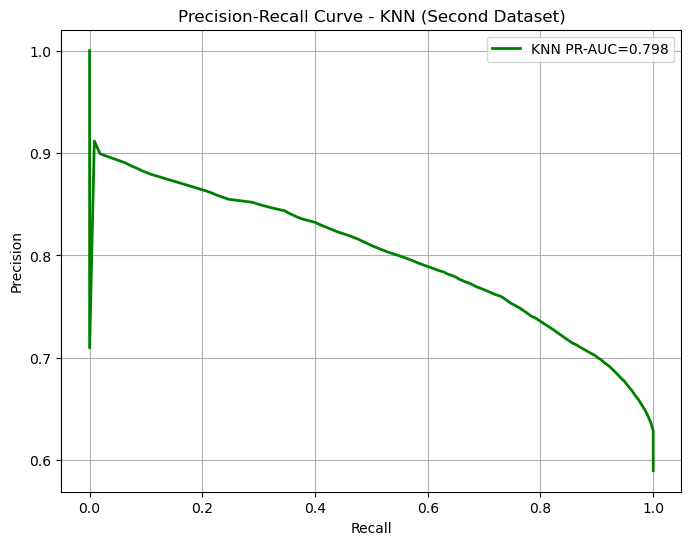

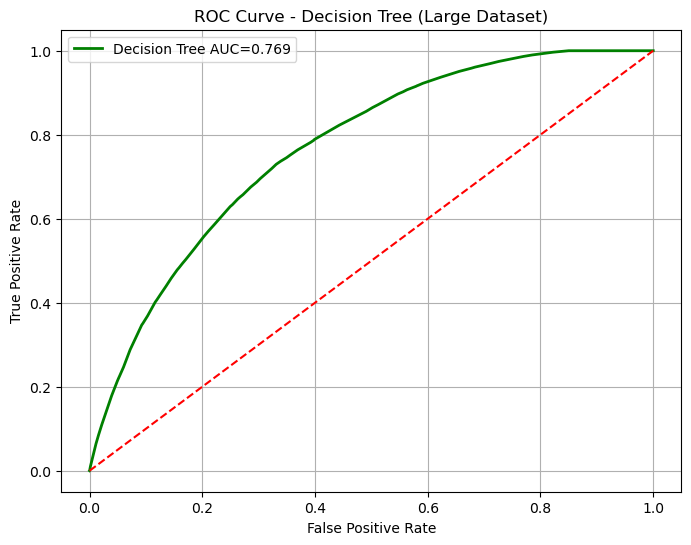

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    balanced_accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt

# --- Compute metrics ---
precision, recall, _ = precision_recall_curve(y_test_ecom, y_test_prob_ecom)
pr_auc = average_precision_score(y_test_ecom, y_test_prob_ecom)

# Predicted labels using 0.5 threshold
y_pred_ecom = (y_test_prob_ecom >= 0.5).astype(int)

f1 = f1_score(y_test_ecom, y_pred_ecom)
bal_acc = balanced_accuracy_score(y_test_ecom, y_pred_ecom)

# --- Baseline (majority class) ---
majority_class = np.bincount(y_test_ecom).argmax()
baseline_preds = np.full_like(y_test_ecom, majority_class)
baseline_bal_acc = balanced_accuracy_score(y_test_ecom, baseline_preds)

# --- Display metrics ---
print(f"  KNN Model Metrics:")
print(f"  • PR-AUC: {pr_auc:.3f}")
print(f"  • F1 Score: {f1:.3f}")
print(f"  • Balanced Accuracy: {bal_acc:.3f}")
print(f"  • Baseline (Majority Class) Balanced Accuracy: {baseline_bal_acc:.3f}")

# --- Plot Precision-Recall Curve ---
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'KNN PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - KNN (Second Dataset)')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# Plot ROC curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test_ecom, y_test_prob_ecom)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Decision Tree AUC={roc_auc_score(y_test_ecom, y_test_prob_ecom):.3f}')
plt.plot([0,1], [0,1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree (Large Dataset)')
plt.legend()
plt.grid(True)
plt.show()


Confusion Matrix (Decision Tree):
 [[156780  91775]
 [ 84328 272968]]


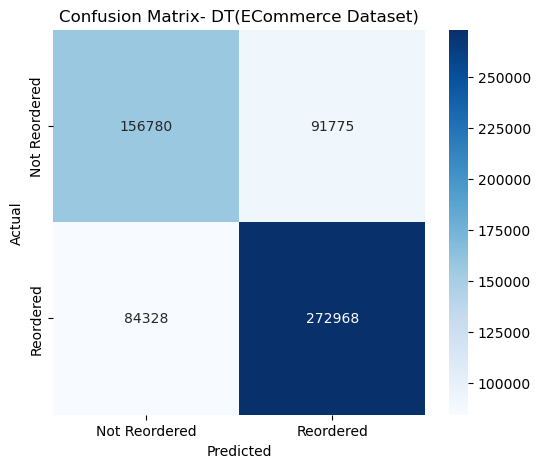

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------------
# Confusion Matrix on Test Set (Decision Tree)
# -----------------------------
y_test_pred_dt = best_dt_ecom.predict(X_test_ecom)  # DT predictions
cm_dt = confusion_matrix(y_test_ecom, y_pred_test_ecom)

print("Confusion Matrix (Decision Tree):\n", cm_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Reordered', 'Reordered'],
            yticklabels=['Not Reordered', 'Reordered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix- DT(ECommerce Dataset)')
plt.show()


Confusion Matrix (Decision Tree):
 [[156780  91775]
 [ 84328 272968]]


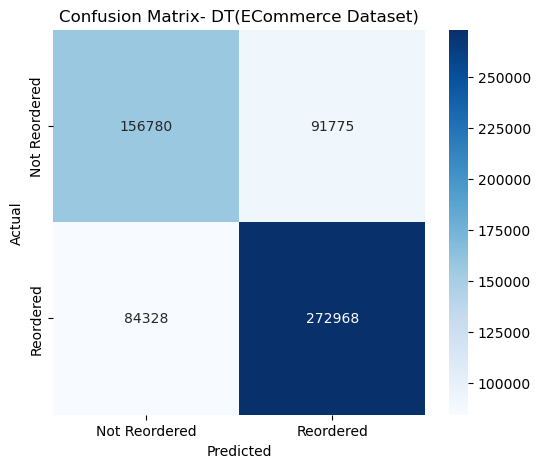

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------------
# Confusion Matrix on Test Set (Decision Tree)
# -----------------------------
y_test_pred_dt = best_dt_ecom.predict(X_test_ecom)  # DT predictions
cm_dt = confusion_matrix(y_test_ecom, y_pred_test_ecom)

print("Confusion Matrix (Decision Tree):\n", cm_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Reordered', 'Reordered'],
            yticklabels=['Not Reordered', 'Reordered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix- DT(ECommerce Dataset)')
plt.show()


## <b>Random Forest</b>

In [ ]:
df_global = pd.read_csv(os.path.join(path1, "Global_Superstore2.csv"), encoding="latin1")
df_ecomm = pd.read_csv(os.path.join(path2, "ECommerce_consumer behaviour.csv"), encoding="latin1")

In [ ]:
def run_eda(df, name="Dataset", max_num_plots=4, sample_n=100_000, use_sample=True):

    lname = (name or "").lower()
    if "global" in lname:
        plot_color, heatmap_cmap = "skyblue", "Blues"
    elif "ecom" in lname or "commerce" in lname:
        plot_color, heatmap_cmap = "plum", "RdPu"
    else:
        plot_color, heatmap_cmap = "steelblue", "viridis"

    # ---- sample for speed on big tables ----
    dfv = df.sample(n=min(sample_n, len(df)), random_state=42) if use_sample else df

    print(f"\nEDA: {name}  | using {len(dfv):,} of {len(df):,} rows")
    print("Shape:", dfv.shape)
    display(dfv.head())

    dupe_mask = dfv.columns.duplicated()
    if dupe_mask.any():
        print(f"[run_eda] Dropping {dupe_mask.sum()} duplicate column(s): "
              f"{dfv.columns[dupe_mask].tolist()}")
        dfv = dfv.loc[:, ~dupe_mask].copy()

    num_cols = dfv.select_dtypes(include=["int64","float64","bool","int32","float32"]).columns.tolist()
    cat_cols = dfv.select_dtypes(include=["object","category"]).columns.tolist()

    # downcast numerics for faster math
    if num_cols:
        dfv.loc[:, num_cols] = (
            dfv.loc[:, num_cols]
               .apply(pd.to_numeric, errors="coerce")
               .astype("float32")
    )
    

    # missing values (on the sampled view)
    miss = dfv.isna().sum()
    display(miss[miss>0].sort_values(ascending=False).head(20))

    # quick stats
    if num_cols:
        display(dfv[num_cols].describe())

    # distributions
    for c in num_cols[:max_num_plots]:
        x = dfv[c].to_numpy(copy=False)
        x = x[~np.isnan(x)]
        plt.hist(x, bins=30, alpha=0.75, color=plot_color)
        plt.title(f"{name}: {c} distribution")
        plt.xlabel(c); plt.tight_layout(); plt.show()

    # correlation heatmap (subset)
    if len(num_cols) >= 2:
        subset = num_cols[:12]
        corr = pd.DataFrame(np.corrcoef(dfv[subset].to_numpy(), rowvar=False),
                            index=subset, columns=subset)
        plt.imshow(corr, cmap=heatmap_cmap, vmin=-1, vmax=1)
        plt.colorbar(); plt.title(f"{name}: correlation heatmap")
        plt.xticks(range(len(subset)), subset, rotation=90)
        plt.yticks(range(len(subset)), subset)
        plt.tight_layout(); plt.show()

    # categorical frequency
    for c in cat_cols[:max_num_plots]:
        vc = dfv[c].value_counts(dropna=False).head(10)
        vc.plot(kind="bar", color=plot_color, title=f"{name}: top categories in '{c}'")
        plt.ylabel("count"); plt.tight_layout(); plt.show()

    return num_cols, cat_cols

The section above is a function that loads the datasets and looks at the shape, info, and head of each data set. Next steps taken in this function are to identify missing values and using imputation to handel them. the Numerical features were imputed with the median meanwhile the categorical ones were imputed with the most frequent value. This is to ensure the model is not biased due to the missing data. 

The function also includes description of statistics. The Global dataset had possible outliers given that the profit values were variable. Whereas the Ecommerce dataset showed there to be consistent frequency in transactions. 

Various visualizations are included in the function. The visualizations in graphs show outliers in various areas and also shows correlations between variables. Categorical variables were encoded as well using ordinal encoder since the one-hot encoder was taking significantlly longer. Numeric variables were standardized.

In [ ]:
def train_rf(X, y, name="Dataset", test_size=0.30, random_state=42):
    
    # ---- color scheme (auto by name) ----
    lname = (name or "").lower()
    if "global" in lname:
        plot_color, heatmap_cmap = "skyblue", "Blues"
    elif "ecom" in lname or "commerce" in lname:
        plot_color, heatmap_cmap = "plum", "RdPu"
    else:
        plot_color, heatmap_cmap = "steelblue", "viridis"  # fallback

    print(f"\nFAST RANDOM FOREST: {name}")

    # Ensure y is 1-D Series
    if isinstance(y, pd.DataFrame):
        y = y.iloc[:, 0]
    y = pd.Series(y).reset_index(drop=True)

    # At least 2 classes
    n_classes = y.dropna().nunique()
    if n_classes < 2:
        raise ValueError(f"{name}: target has <2 classes (found {n_classes}).")

    # Split (stratify for classification)
    stratify_arg = y if n_classes >= 2 else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg)

    # Columns
    num_cols = X_train.select_dtypes(include=["int64", "float64", "bool", "int32", "float32"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    # Pipelines
    num_pipe = SimpleImputer(strategy="median")
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    prep = ColumnTransformer(
        [("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
        remainder="drop",
        verbose_feature_names_out=False)

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=14,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1,)

    pipe = Pipeline([("prep", prep), ("rf", rf)])
    pipe.fit(X_train, y_train)

    # --- Eval ---
    y_pred = pipe.predict(X_test)
    print("\nAccuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # --- ROC/AUC (binary only) ---
    if n_classes == 2 and hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        fpr, tpr, _ = roc_curve(y_test, y_prob)        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, lw=2, color=plot_color, label=f"AUC={auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve – {name}")
        plt.legend(); plt.grid(True, linestyle="--", alpha=0.6); plt.tight_layout(); plt.show()


        # --- Precision-Recall AUC (PR-AUC) ---
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        
        print(f"ROC-AUC: {auc:.3f}")
        print(f"PR-AUC:  {pr_auc:.3f}")

        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, color=plot_color, label=f"PR curve (area = {pr_auc:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve - {name}")
        plt.legend()
        plt.show()
        

    # --- Feature importances (Top 15) ---
    importances = pipe.named_steps["rf"].feature_importances_
    feat_names = num_cols + cat_cols
    # Guard against length mismatch (can happen with dropna etc.)
    if len(importances) != len(feat_names):
        feat_names = [f"Feature_{i}" for i in range(len(importances))]
    order = np.argsort(importances)[-15:]
    top_feats = np.array(feat_names)[order]
    top_imps = importances[order]

    plt.figure(figsize=(10, 6))
    plt.barh(top_feats[::-1], top_imps[::-1], color=plot_color)
    plt.title(f"Top 15 Feature Importances – {name}")
    plt.tight_layout(); plt.show()

    return pipe

This fucntion performs Random Forest on the following two datasets: Global and Ecommerce.

On the E-Commerce dataset, the classifier was trained to predict if a customer would reorder an item.

On the Global dataset, the classier was trained on customer value and with profits above 0.75 labeled as "high" and the rest as "low."


EDA: E-commerce  | using 100,000 of 1,895,159 rows
Shape: (100000, 8)


,department,product_name,order_number,order_dow,order_hour_of_day,add_to_cart_order,days_since_prior_order,reordered
830709,frozen,frozen breakfast,23,2,8,2,4.0,0
814901,snacks,fruit vegetable snacks,11,0,12,3,4.0,0
1618415,household,plates bowls cups flatware,27,6,8,13,3.0,0
395324,household,food storage,3,3,19,25,10.0,0
1586961,dry goods pasta,instant foods,32,6,20,3,8.0,0


Series([], dtype: int64)

,order_number,order_dow,order_hour_of_day,add_to_cart_order,days_since_prior_order,reordered
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000
mean,18.177760,2.733410,13.424870,8.36526,11.39047,0.628630
std,17.563909,2.094627,4.262452,7.15166,8.96083,0.483174
min,2.000000,0.000000,0.000000,1.00000,0.00000,0.000000
25%,6.000000,1.000000,10.000000,3.00000,5.00000,0.000000
50%,12.000000,3.000000,13.000000,6.00000,8.00000,1.000000
75%,25.000000,5.000000,16.000000,11.00000,15.00000,1.000000
max,100.000000,6.000000,23.000000,111.00000,30.00000,1.000000


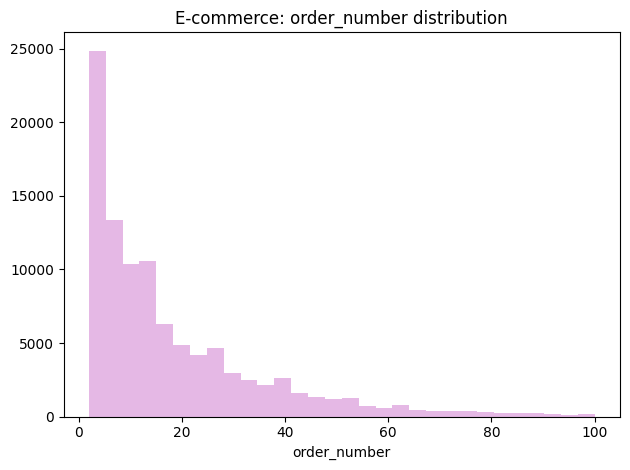

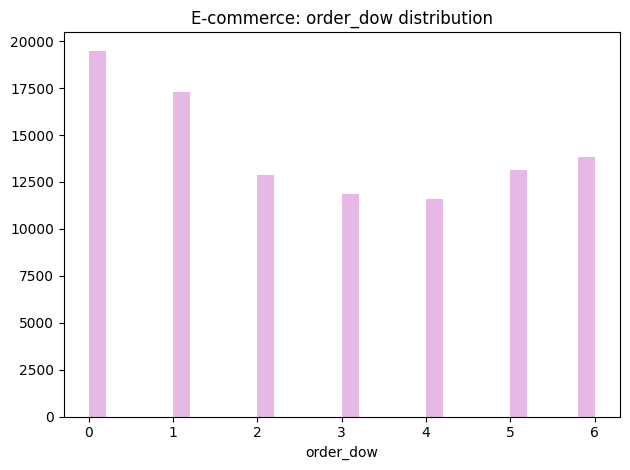

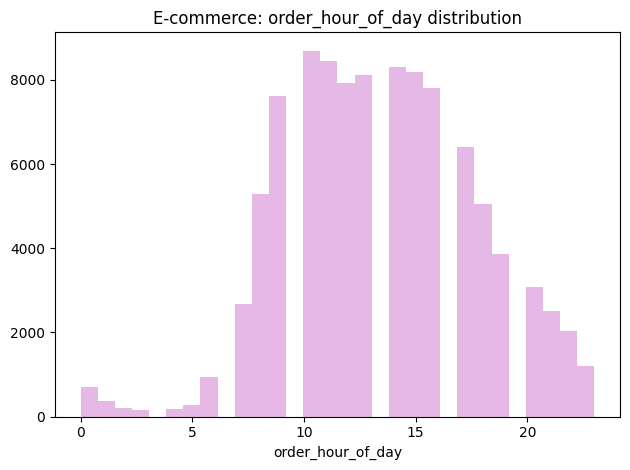

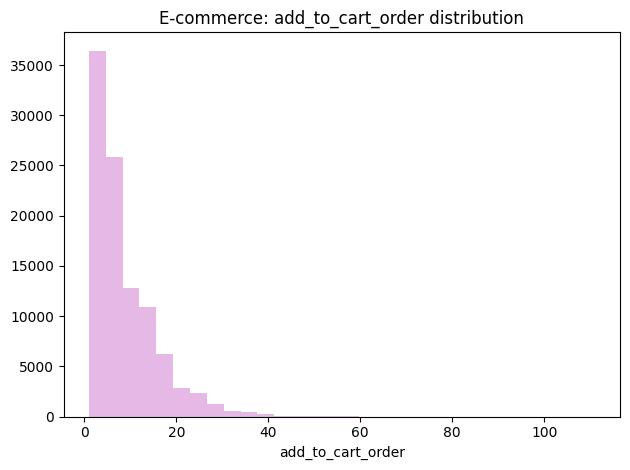

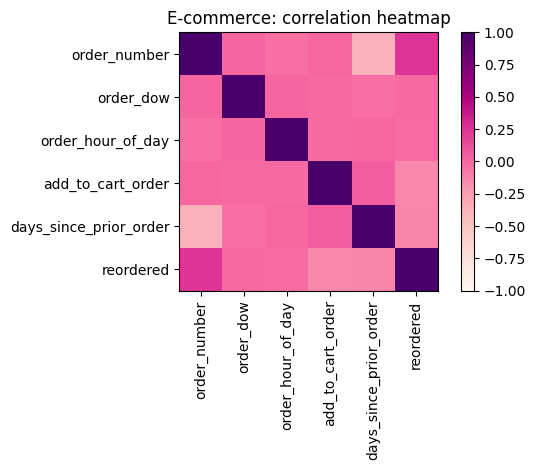

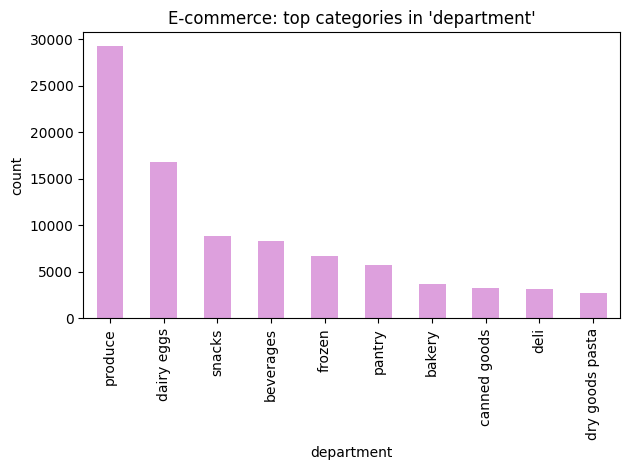

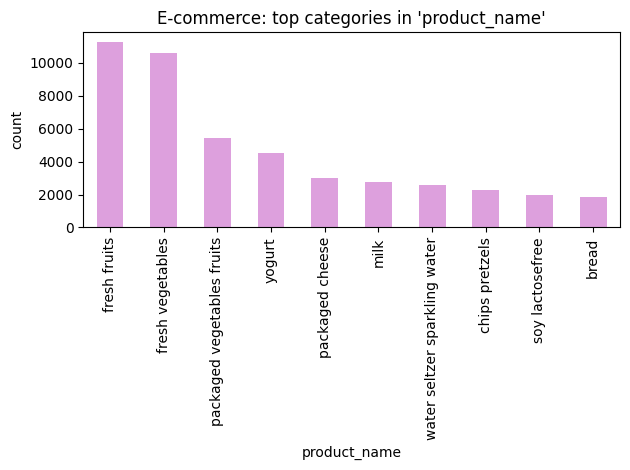


FAST RANDOM FOREST: E-commerce

Accuracy: 0.6945851537601047

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.66      0.61    211252
           1       0.78      0.72      0.75    357296

    accuracy                           0.69    568548
   macro avg       0.68      0.69      0.68    568548
weighted avg       0.70      0.69      0.70    568548


Confusion Matrix:
 [[138591  72661]
 [100982 256314]]


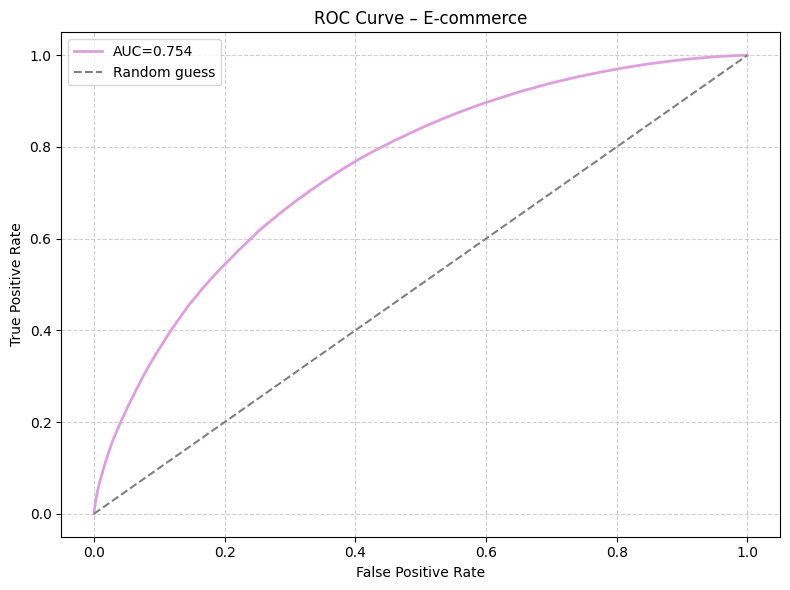

ROC-AUC: 0.754
PR-AUC:  0.823


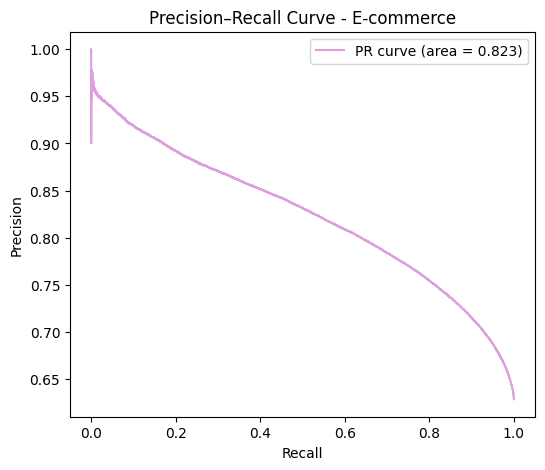

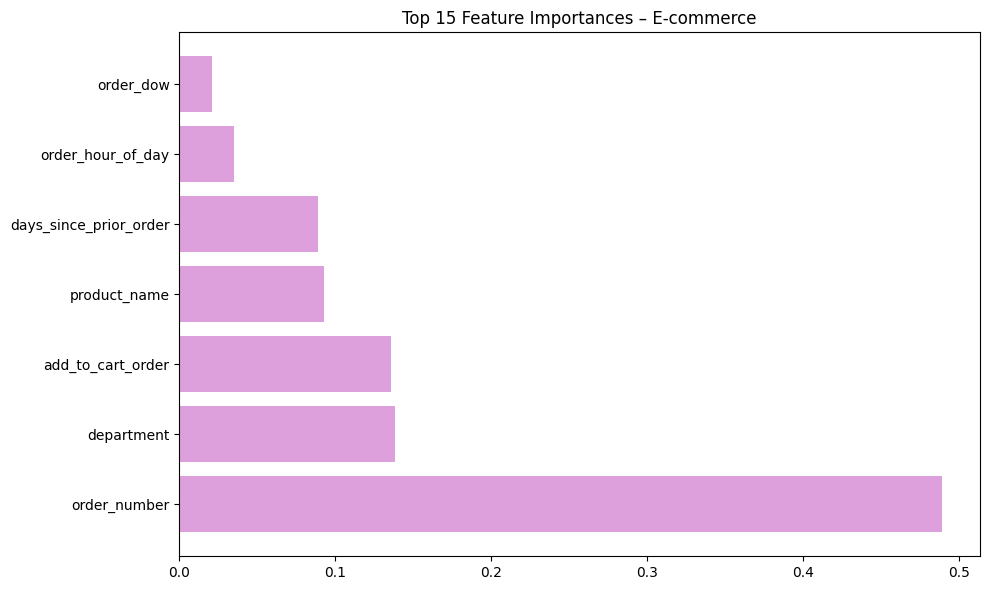

In [ ]:
# Build dataset ECOMMERCE
df_e = df_ecomm.copy()

categorical_cols = ['department', 'product_name']
numeric_cols = ['order_number', 'order_dow', 'order_hour_of_day','add_to_cart_order', 'days_since_prior_order']
target_col = 'reordered'

# Keep required columns, drop Na
df_e = df_e[categorical_cols + numeric_cols + [target_col]].dropna()

# EDA 
run_eda(df_e, "E-commerce")

# Train Random Forest
X_e = df_e[categorical_cols + numeric_cols]
y_e = df_e[target_col].astype(int)
rf_e = train_rf(X_e, y_e, "E-commerce")


EDA: Global Superstore  | using 51,290 of 51,290 rows
Shape: (51290, 13)


,Sales,Quantity,Discount,Shipping Cost,ValueLabel,Ship Mode,Segment,Market,Region,Category,Sub-Category,Order Priority,ValueLabel
49728,5.868,3,0.4,0.41,0,Standard Class,Consumer,LATAM,Central,Office Supplies,Binders,Medium,0
45547,10.368,2,0.2,1.14,1,Same Day,Consumer,US,Central,Office Supplies,Paper,High,1
15664,269.220,2,0.0,18.52,1,Standard Class,Corporate,EU,Central,Office Supplies,Storage,Medium,1
40561,43.176,3,0.2,2.12,1,Standard Class,Consumer,US,West,Office Supplies,Art,Medium,1
49426,5.712,1,0.4,0.48,0,Standard Class,Corporate,LATAM,Central,Office Supplies,Art,Medium,0


[run_eda] Dropping 1 duplicate column(s): ['ValueLabel']


Series([], dtype: int64)

,Sales,Quantity,Discount,Shipping Cost,ValueLabel
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490581,3.476545,0.142908,26.375915,0.725814
std,487.565359,2.278766,0.212280,57.296804,0.446108
min,0.444000,1.000000,0.000000,0.000000,0.000000
25%,30.758626,2.000000,0.000000,2.610000,0.000000
50%,85.053001,3.000000,0.000000,7.790000,1.000000
75%,251.053196,5.000000,0.200000,24.450001,1.000000
max,22638.480469,14.000000,0.850000,933.570007,1.000000


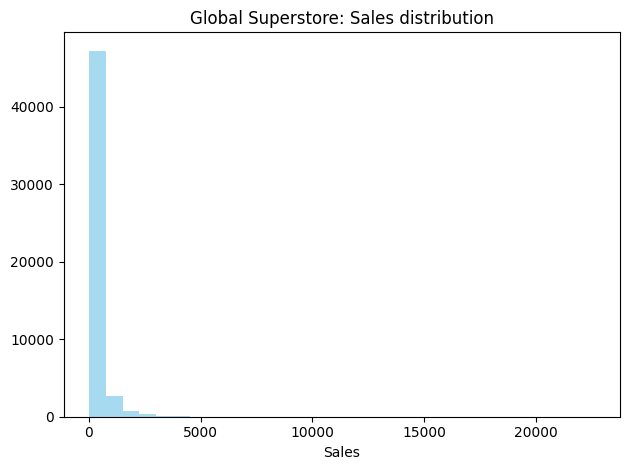

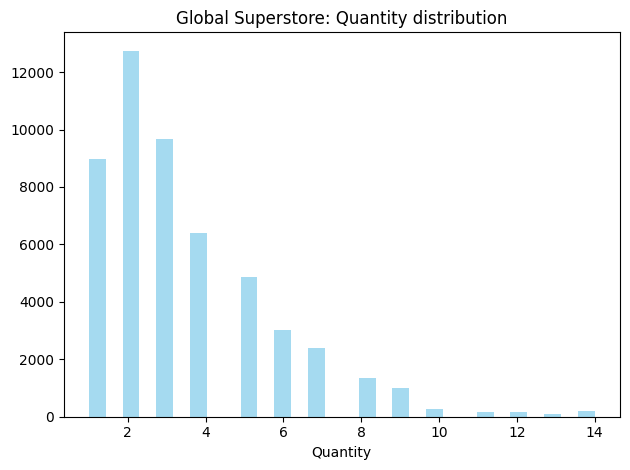

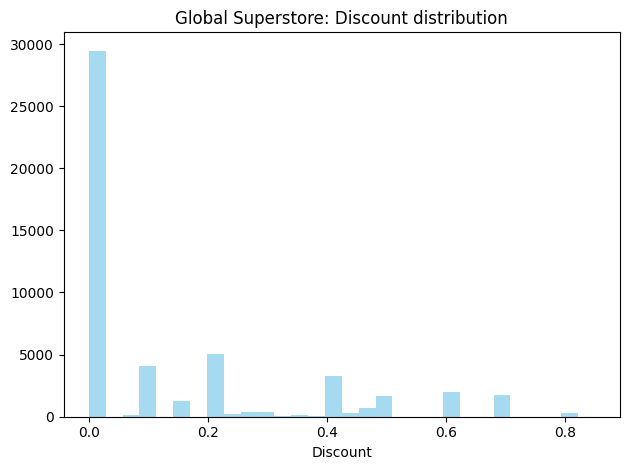

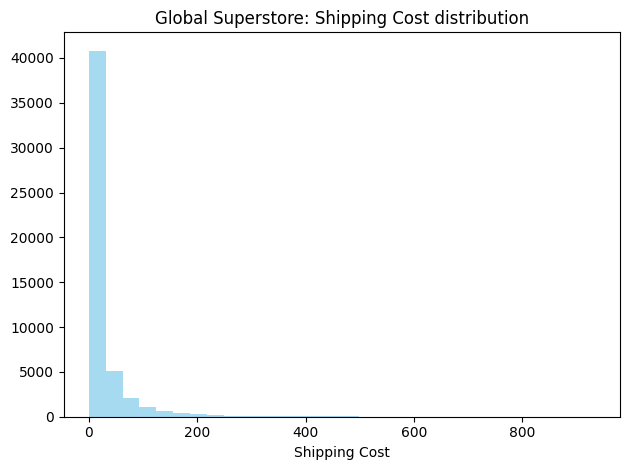

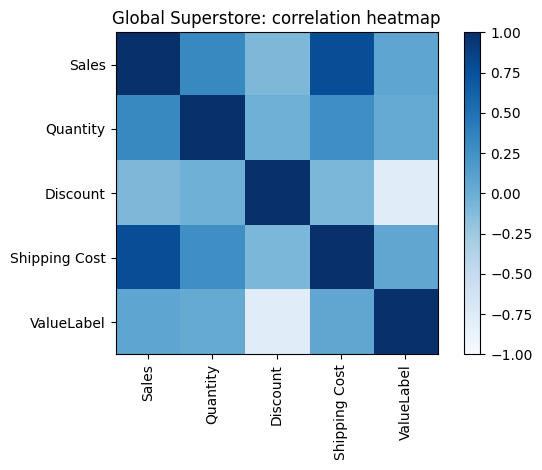

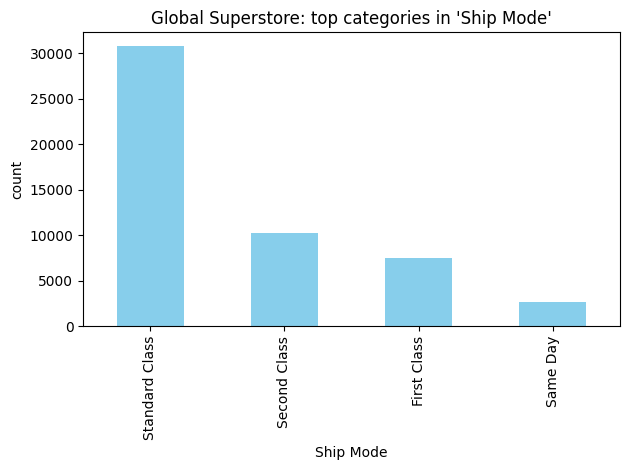

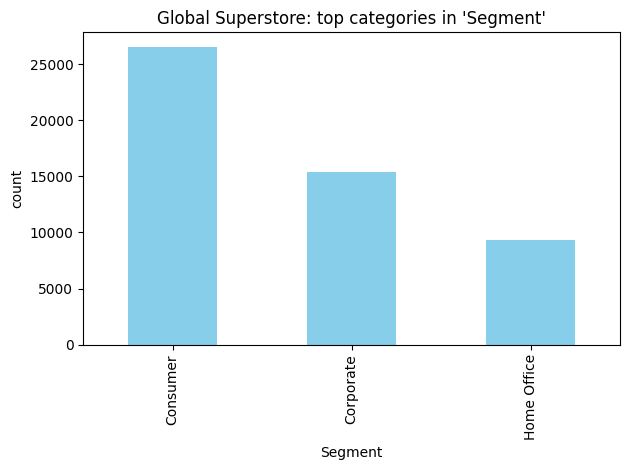

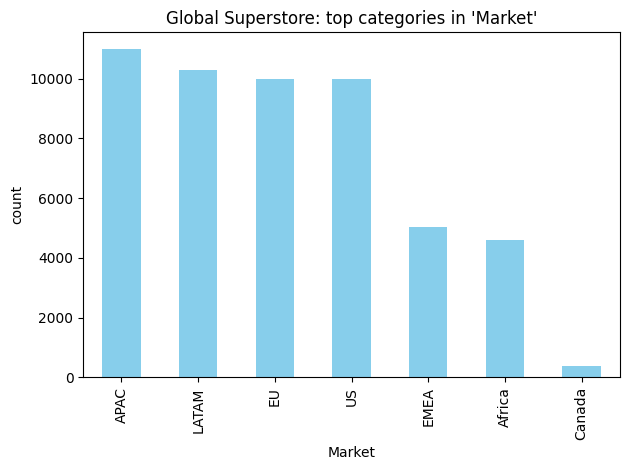

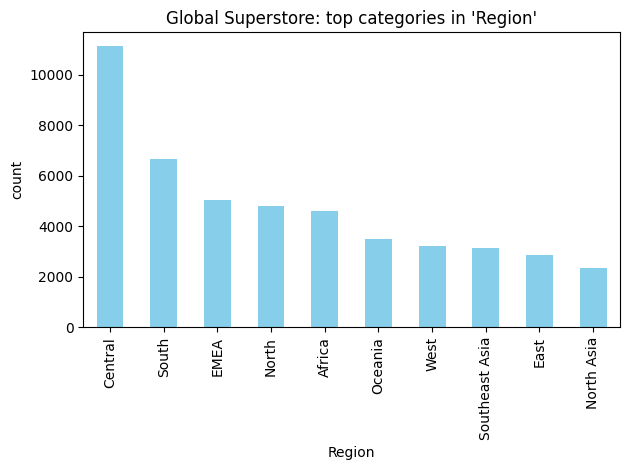


FAST RANDOM FOREST: Global Superstore

Accuracy: 0.8964060570611555

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81      4219
           1       0.92      0.93      0.93     11168

    accuracy                           0.90     15387
   macro avg       0.87      0.86      0.87     15387
weighted avg       0.90      0.90      0.90     15387


Confusion Matrix:
 [[ 3351   868]
 [  726 10442]]


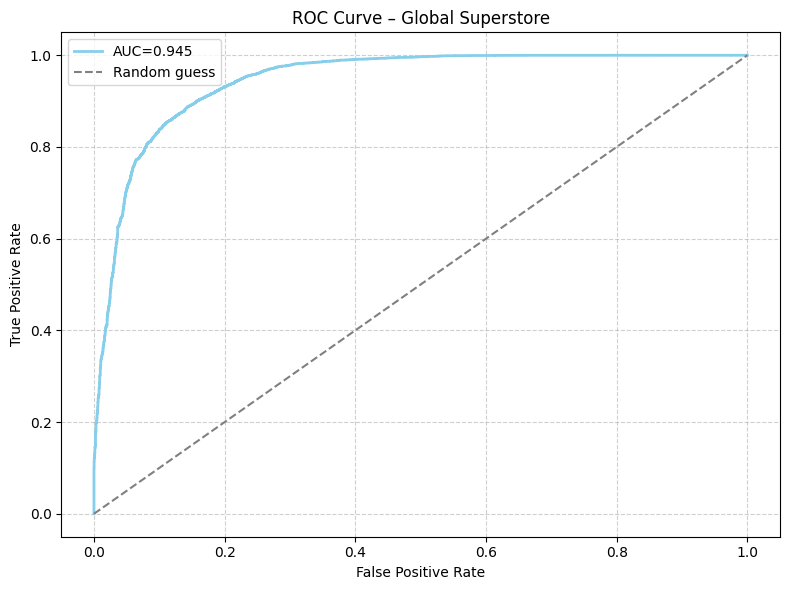

ROC-AUC: 0.945
PR-AUC:  0.974


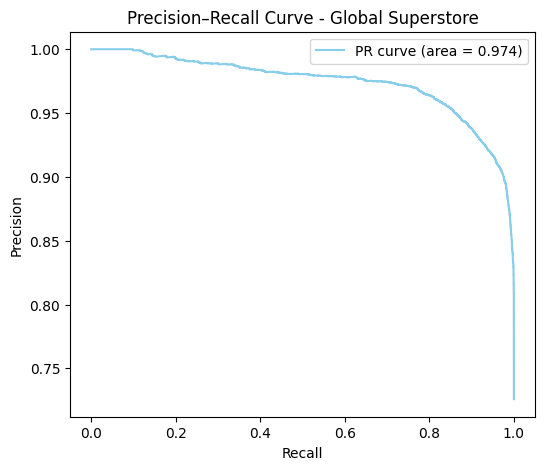

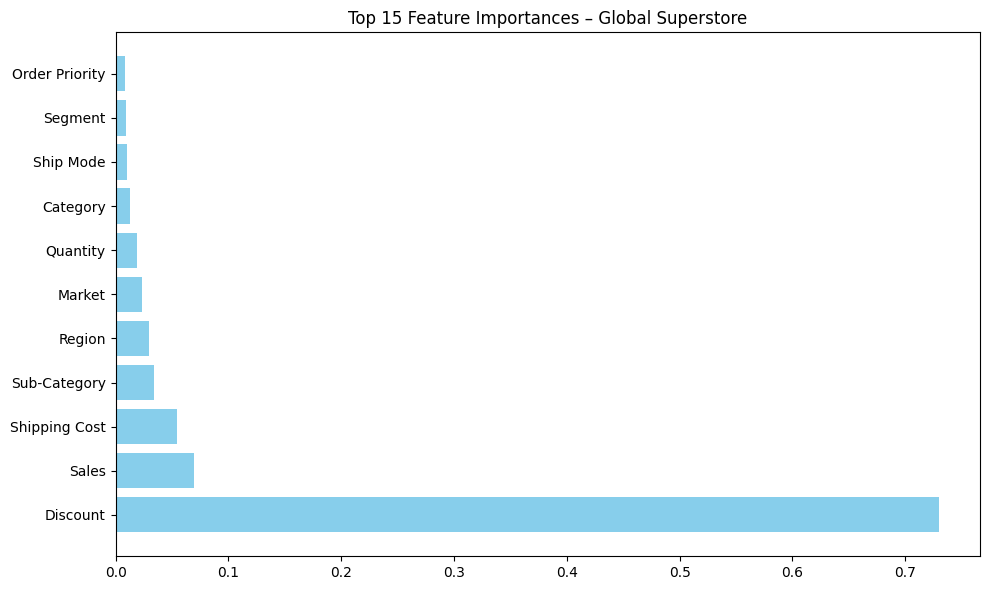

In [ ]:
# Build dataset GLOBAL
df_g = df_global.copy()
df_g = df_g.loc[:, ~df_g.columns.duplicated()].copy()   # <-- add this

# Dates
for c in ['Order Date','Ship Date','OrderDate','ShipDate']:
    if c in df_g.columns:
        df_g[c] = pd.to_datetime(df_g[c], errors='coerce')

# High value if Profit > 0.75
df_g = df_g.dropna(subset=['Profit'])
df_g['ValueLabel'] = (df_g['Profit'] > 0.75).astype(int)

# Drop heavy data to keep it faster
drop_cols = ['Profit','Order Date','Ship Date','Order ID','Customer ID','Row ID','Postal Code','Product ID','Product Name']
df_g = df_g.drop(columns=[c for c in drop_cols if c in df_g.columns], errors='ignore')

# keep numeric 
num_cols_g = df_g.select_dtypes(include=['int64','float64','bool']).columns.tolist()
cat_all_g  = df_g.select_dtypes(include=['object','category']).columns.tolist()
cat_cols_g = [c for c in cat_all_g if df_g[c].nunique(dropna=True) <= 50]

use_cols_g = num_cols_g + cat_cols_g + ['ValueLabel']
df_g = df_g[use_cols_g].dropna(how='all')

# EDA
run_eda(df_g, "Global Superstore")

# Train Random Forest
X_g = df_g.drop(columns=['ValueLabel'])
y_g = df_g['ValueLabel']
rf_g = train_rf(X_g, y_g, "Global Superstore")

## <b>XG-Boost</b>


### E-Commerce Dataset

In [ ]:

# ---------------------------
# Train/Test Split
# ---------------------------
X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_imputed, y_global, test_size=0.3, random_state=42, stratify=y_global
)

# ---------------------------
# Standardize numeric features
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_global)
X_test_scaled = scaler.transform(X_test_global)

# ---------------------------
# Handle class imbalance using adaptive SMOTE
# ---------------------------
class_counts = Counter(y_train_global)
minority_class = min(class_counts, key=class_counts.get)
majority_class = max(class_counts, key=class_counts.get)
ratio = class_counts[minority_class] / class_counts[majority_class]

print(f"Class distribution before SMOTE: {class_counts}")
print(f"Minority/Majority ratio: {ratio:.4f}")

# Decide sampling ratio automatically
if ratio < 0.05:
    sampling_strategy = 0.5   # extremely imbalanced
elif ratio < 0.2:
    sampling_strategy = 0.8   # moderately imbalanced
else:
    sampling_strategy = 1.0   # near balanced

print(f"Using sampling_strategy={sampling_strategy}")

sm = SMOTE(random_state=42, sampling_strategy=sampling_strategy)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train_global)
print(f"After SMOTE: {Counter(y_train_resampled)}\n")

# ---------------------------
# Define XGBoost model and search space (efficient version)
# ---------------------------
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',    # histogram algorithm = faster
    predictor='auto'
)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 2]
}

# ---------------------------
# Randomized Search with 3-Fold CV
# ---------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

start_time = time.time()
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,            # fewer iterations for speed
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

# ---------------------------
# Evaluate best model
# ---------------------------
best_xgb = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)
print(f"Training time: {end_time - start_time:.2f} seconds\n")

# ---------------------------
# Test performance
# ---------------------------
y_pred_global = best_xgb.predict(X_test_scaled)
y_prob_test_global = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test_global, y_pred_global))
print("Test ROC-AUC:", roc_auc_score(y_test_global, y_prob_test_global))
print("Test PR-AUC:", average_precision_score(y_test_global, y_prob_test_global))
print("\nClassification Report:\n", classification_report(y_test_global, y_pred_global))



Class distribution before SMOTE: Counter({0.0: 20912, 1.0: 14991})
Minority/Majority ratio: 0.7169
Using sampling_strategy=1.0
After SMOTE: Counter({0.0: 20912, 1.0: 20912})

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.9447859851807251
Training time: 8.82 seconds

Test Accuracy: 0.8184831351140573
Test ROC-AUC: 0.9362804560891338
Test PR-AUC: 0.9142074980621602

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.73      0.82      8962
         1.0       0.71      0.95      0.81      6425

    accuracy                           0.82     15387
   macro avg       0.83      0.84      0.82     15387
weighted avg       0.85      0.82      0.82     15387



In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Predicted probabilities and labels from XGBoost
# ---------------------------
y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# ---------------------------
# Compute metrics
# ---------------------------
precision, recall, _ = precision_recall_curve(y_test_global, y_prob)
pr_auc = average_precision_score(y_test_global, y_prob)
f1 = f1_score(y_test_global, y_pred)
bal_acc = balanced_accuracy_score(y_test_global, y_pred)

# Baseline (majority class)
majority_class = np.bincount(y_test_global).argmax()
baseline_preds = np.full_like(y_test_global, majority_class)
baseline_bal_acc = balanced_accuracy_score(y_test_global, baseline_preds)

# ---------------------------
# Display metrics
# ---------------------------
print(f" XGBoost Model Metrics (Global Dataset):")
print(f"  • PR-AUC: {pr_auc:.3f}")
print(f"  • F1 Score: {f1:.3f}")
print(f"  • Balanced Accuracy: {bal_acc:.3f}")
print(f"  • Baseline (Majority Class) Balanced Accuracy: {baseline_bal_acc:.3f}")

# ---------------------------
# Plot Precision-Recall Curve
# ---------------------------
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'XGBoost PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost (Global Dataset)')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# Plot ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test_global, y_prob)
roc_auc = roc_auc_score(y_test_global, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', linewidth=2, label=f'XGBoost AUC={roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (Global Dataset)')
plt.legend()
plt.grid(True)
plt.show()


Confusion Matrix (XGBoost):
 [[6499 2463]
 [ 330 6095]]


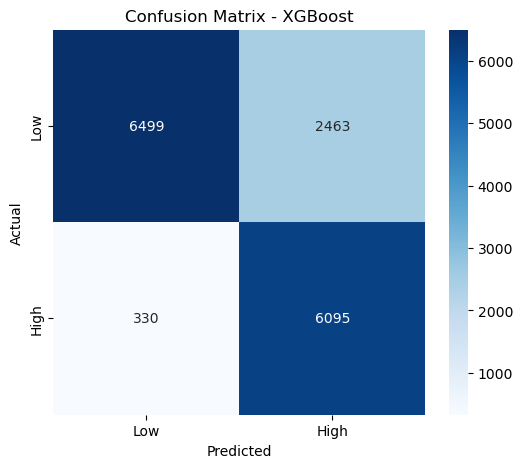

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Predict on test set using 0.5 threshold
# ---------------------------
y_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# ---------------------------
# Compute confusion matrix
# ---------------------------
cm = confusion_matrix(y_test_global, y_pred)
print("Confusion Matrix (XGBoost):\n", cm)

# ---------------------------
# Plot confusion matrix
# ---------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()




Top 10 Feature Importance (XGBoost):
               feature  importance
7               region    0.190978
6               market    0.126497
12            quantity    0.077984
13            discount    0.066616
2              segment    0.061349
1        customer_name    0.054439
23           ship_year    0.037866
18  order_weekday_name    0.028300
24          ship_month    0.027682
17       order_weekday    0.026537


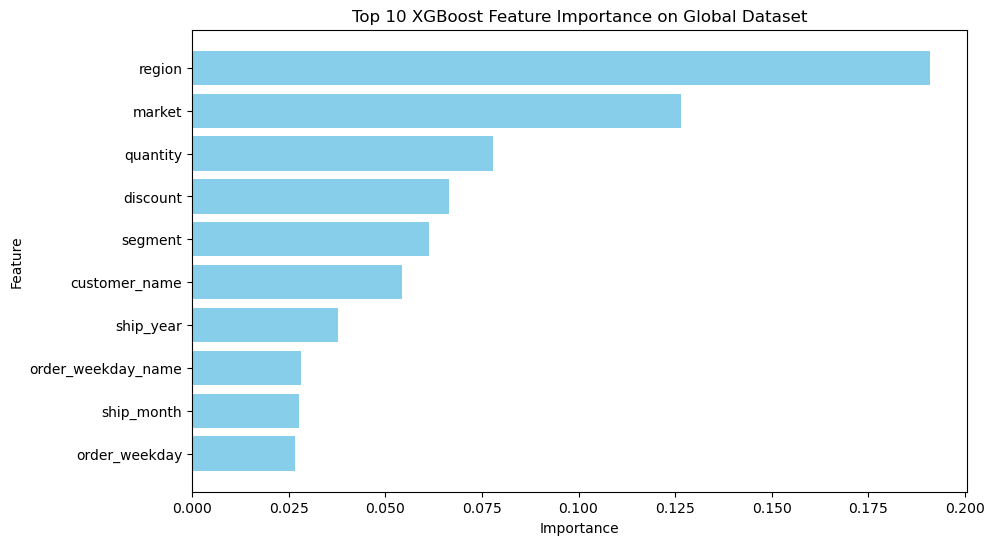

In [ ]:
# ---------------------------
# Feature Importance (Top 10)
# ---------------------------
feat_importance = pd.DataFrame({
    'feature': df_clean.drop('customer_value', axis=1).columns,
    'importance': best_xgb.feature_importances_
}).sort_values(by='importance', ascending=False).head(10)  # keep top 10

print("\nTop 10 Feature Importance (XGBoost):")
print(feat_importance)

# --- Plot top 10 feature importance ---
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['feature'], feat_importance['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 XGBoost Feature Importance on Global Dataset")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


### <b>E-Commerce</b>

In [ ]:
# --- Imports ---
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance
import seaborn as sns

# ---------------------------
# Drop non-predictive columns
# ---------------------------
drop_cols = ['order_id', 'user_id', 'product_id', 'days_since_prior_order', 'department_id']
df_ecom_clean = df2.drop(columns=drop_cols, errors='ignore')

# ---------------------------
# Encode categorical columns
# ---------------------------
for col in df_ecom_clean.select_dtypes(include='object'):
    df_ecom_clean[col] = df_ecom_clean[col].astype('category').cat.codes

# ---------------------------
# Handle missing values
# ---------------------------
imputer = SimpleImputer(strategy='median')
X_ecom = df_ecom_clean.drop('reordered', axis=1)
y_ecom = df_ecom_clean['reordered']
X_ecom_imputed = imputer.fit_transform(X_ecom)

# ---------------------------
# Train/Test Split
# ---------------------------
X_train_ecom, X_test_ecom, y_train_ecom, y_test_ecom = train_test_split(
    X_ecom_imputed, y_ecom, test_size=0.3, random_state=42, stratify=y_ecom
)

# ---------------------------
# Standardize numeric features
# ---------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ecom)
X_test_scaled = scaler.transform(X_test_ecom)

# ---------------------------
# Handle class imbalance using adaptive SMOTE
# ---------------------------
class_counts = Counter(y_train_ecom)
minority_class = min(class_counts, key=class_counts.get)
majority_class = max(class_counts, key=class_counts.get)
ratio = class_counts[minority_class] / class_counts[majority_class]

print(f"Class distribution before SMOTE: {class_counts}")
print(f"Minority/Majority ratio: {ratio:.4f}")

# Decide sampling ratio automatically
if ratio < 0.05:
    sampling_strategy = 0.5
elif ratio < 0.2:
    sampling_strategy = 0.8
else:
    sampling_strategy = 1.0

print(f"Using sampling_strategy={sampling_strategy}")

sm = SMOTE(random_state=42, sampling_strategy=sampling_strategy)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train_ecom)
print(f"After SMOTE: {Counter(y_train_resampled)}\n")

# ---------------------------
# Define XGBoost model and search space
# ---------------------------
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    predictor='auto'
)

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [4, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 2]
}

# ---------------------------
# Randomized Search with 3-Fold CV
# ---------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

start_time = time.time()
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,  # fewer iterations for speed
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train_resampled, y_train_resampled)
end_time = time.time()

# ---------------------------
# Evaluate best model
# ---------------------------
best_xgb_ecom = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)
print(f"Training time: {end_time - start_time:.2f} seconds\n")

# ---------------------------
# Test performance
# ---------------------------
y_pred_ecom = best_xgb_ecom.predict(X_test_scaled)
y_prob_ecom = best_xgb_ecom.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test_ecom, y_pred_ecom))
print("Test ROC-AUC:", roc_auc_score(y_test_ecom, y_prob_ecom))
print("Test PR-AUC:", average_precision_score(y_test_ecom, y_prob_ecom))
print("\nClassification Report:\n", classification_report(y_test_ecom, y_pred_ecom))

# --- PR-AUC and Additional Metrics ---
from sklearn.metrics import precision_recall_curve, f1_score, balanced_accuracy_score

# Predicted labels using 0.5 threshold
y_pred_labels = (y_prob_ecom >= 0.5).astype(int)

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test_ecom, y_prob_ecom)
pr_auc = average_precision_score(y_test_ecom, y_prob_ecom)

# F1 and balanced accuracy
f1 = f1_score(y_test_ecom, y_pred_labels)
bal_acc = balanced_accuracy_score(y_test_ecom, y_pred_labels)

# Baseline (majority class)
majority_class = np.bincount(y_test_ecom).argmax()
baseline_preds = np.full_like(y_test_ecom, majority_class)
baseline_bal_acc = balanced_accuracy_score(y_test_ecom, baseline_preds)

# Print metrics
print(f"\nXGBoost Metrics (E-commerce Dataset):")
print(f" • PR-AUC: {pr_auc:.3f}")
print(f" • F1 Score: {f1:.3f}")
print(f" • Balanced Accuracy: {bal_acc:.3f}")
print(f" • Baseline Balanced Accuracy: {baseline_bal_acc:.3f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='green', linewidth=2, label=f'XGBoost PR-AUC={pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost (E-commerce)')
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------
# ROC Curve
# ---------------------------
fpr, tpr, _ = roc_curve(y_test_ecom, y_prob_ecom)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', linewidth=2, label=f'XGBoost AUC = {roc_auc_score(y_test_ecom, y_prob_ecom):.3f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix (XGBoost):
 [[145731 102824]
 [ 61581 295715]]


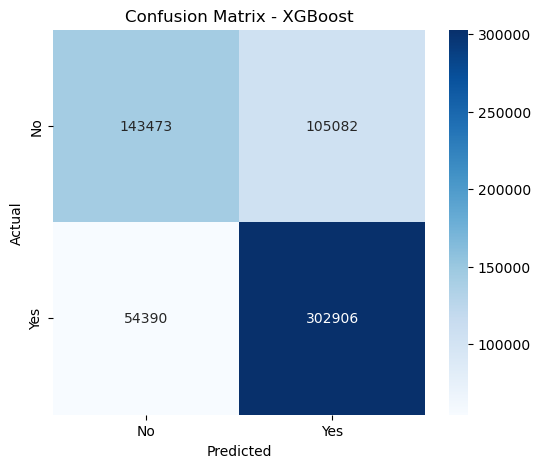

In [ ]:
# ---------------------------
# Confusion Matrix
# ---------------------------
cm_xg = confusion_matrix(y_test_ecom, y_pred_ecom)
print("Confusion Matrix (XGBoost):\n", cm_xg)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()


Top 10 Feature Importance (XGBoost):
             feature  importance
0       order_number    0.456066
3  add_to_cart_order    0.194882
4         department    0.185726
5       product_name    0.112646
2  order_hour_of_day    0.028627
1          order_dow    0.022052


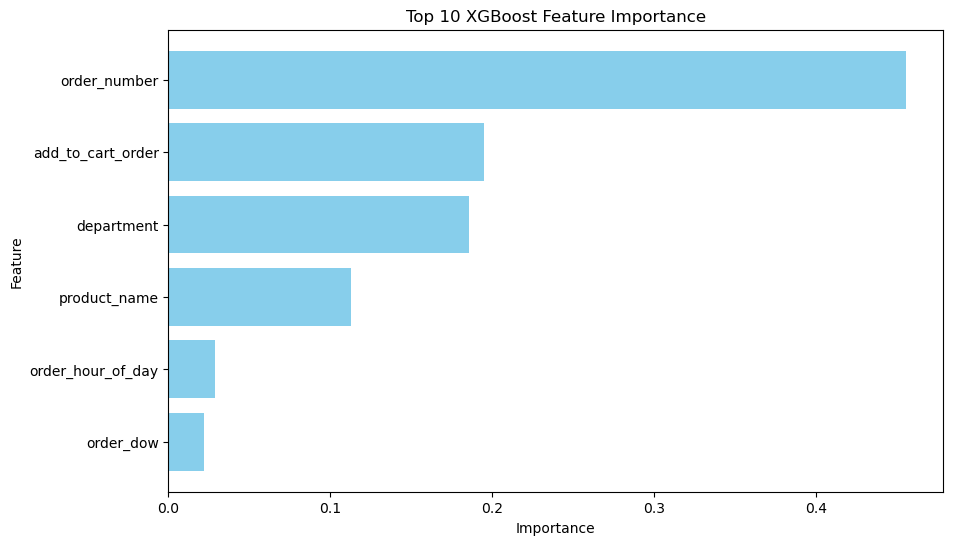

In [ ]:

# ---------------------------
# Feature Importance (Top 10)
# ---------------------------
feat_importance = pd.DataFrame({
    'feature': df_ecom_clean.drop('reordered', axis=1).columns,
    'importance': best_xgb_ecom.feature_importances_
}).sort_values(by='importance', ascending=False).head(10)

print("\nTop 10 Feature Importance (XGBoost):")
print(feat_importance)

plt.figure(figsize=(10,6))
plt.barh(feat_importance['feature'], feat_importance['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## <b>Results</b> 

In [7]:
rows = [
    # --------- E-Commerce ----------
    {"Model": "KNN",            "Dataset": "E-Commerce", "PR-AUC": 0.798, "F1": 0.756, "Balanced Accuracy": 0.697},
    {"Model": "Decision Tree",  "Dataset": "E-Commerce", "PR-AUC": 0.798, "F1": 0.710, "Balanced Accuracy": 0.709},  
    {"Model": "Random Forest",  "Dataset": "E-Commerce", "PR-AUC": 0.823, "F1": 0.70, "Balanced Accuracy": 0.694},  

    # --------- Global --------------
    {"Model": "KNN",            "Dataset": "Global",     "PR-AUC": 0.640, "F1": 0.673, "Balanced Accuracy": 0.681},
    {"Model": "Decision Tree",  "Dataset": "Global",     "PR-AUC": 0.640, "F1":  0.653, "Balanced Accuracy":  0.652},  
    {"Model": "Random Forest",  "Dataset": "Global",     "PR-AUC": 0.974, "F1": 0.90, "Balanced Accuracy": 0.8964},  
]

summary = pd.DataFrame(rows)

sort_cols = [c for c in ["PR-AUC", "F1", "Balanced Accuracy"] if c in summary.columns]
summary = summary.sort_values(by=sort_cols, ascending=[False]*len(sort_cols), kind="mergesort").reset_index(drop=True)

print("=== Final Model Comparison ===")
display(summary)

=== Final Model Comparison ===


,Model,Dataset,PR-AUC,F1,Balanced Accuracy
0,Random Forest,Global,0.974,0.900,0.8964
1,Random Forest,E-Commerce,0.823,0.700,0.6940
2,KNN,E-Commerce,0.798,0.756,0.6970
3,Decision Tree,E-Commerce,0.798,0.710,0.7090
4,KNN,Global,0.640,0.673,0.6810
5,Decision Tree,Global,0.640,0.653,0.6520


Six models were evaluated — K-Nearest Neighbors (KNN), Decision Tree, and Random Forest — each trained and tested on both the E-Commerce and Global datasets. Model performance was assessed using Precision–Recall AUC (PR-AUC), F1 Score, and Balanced Accuracy, providing a balanced view of precision–recall trade-offs and sensitivity to class imbalance.

The Random Forest (Global) model outperformed all others, achieving a PR-AUC of 0.974, F1 Score of 0.900, and Balanced Accuracy of 0.896, indicating superior generalization and robustness across the broader dataset. This result underscores the strength of ensemble averaging in capturing complex, nonlinear feature relationships while reducing overfitting.

Among the E-Commerce models, Random Forest again demonstrated the best overall performance (PR-AUC = 0.823), though its F1 Score (0.700) was slightly lower than that of the KNN model (0.756). The KNN (E-Commerce) model exhibited strong precision–recall balance, suggesting that neighborhood-based classification performs well when customer behavior patterns are dense, consistent, and well-structured.

The Decision Tree models, while interpretable, produced the lowest overall scores — particularly on the Global dataset (PR-AUC = 0.640). Their performance drop relative to Random Forest highlights the advantage of ensemble diversity over single-tree learners, which are more prone to overfitting and limited in modeling nonlinear dependencies.

These results suggest that:

Random Forest provides the most consistent and accurate performance across both datasets.

KNN (E-Commerce) offers strong predictive balance for smaller, homogeneous datasets.

Decision Trees, though valuable for interpretability, are less competitive in predictive accuracy.

Ensemble learning (Random Forest) delivers the most robust and generalizable results, especially for complex or heterogeneous datasets such as the Global sample.

The observed performance gap between models highlights how algorithmic complexity and data diversity influence predictive outcomes. The Random Forest (Global) model’s superior metrics (PR-AUC = 0.974, F1 = 0.900, Balanced Accuracy = 0.896) indicate that ensemble methods excel in heterogeneous datasets, where feature interactions and nonlinear decision boundaries are prevalent. Random Forest’s aggregation of multiple, decorrelated trees enables it to capture subtle, region-specific patterns while minimizing variance, making it especially effective for large-scale, globally diverse consumer behavior prediction.

In contrast, the KNN (E-Commerce) model’s strong performance reflects how instance-based learning can excel in smaller, well-clustered datasets. Its reliance on proximity-based similarity is advantageous when data points exhibit coherent local structure and limited noise, as is common in focused, single-market consumer data.

The Decision Tree models, though interpretable and computationally efficient, exhibited weaker generalization due to their tendency to overfit and their limited ability to capture intricate feature relationships. This reinforces the trade-off between interpretability and predictive performance, a crucial consideration in applied analytics.

Overall, these findings emphasize that model selection should be guided by dataset scale and complexity. Ensemble approaches such as Random Forest are best suited for diverse, multi-domain data, while instance-based algorithms like KNN perform optimally in localized or domain-specific contexts.